# Final Notebook!

## Making a fully general emcee pipeline!

So in the last notebook, I made all our helper functions general and saw SOME success in our full emcee pipeline

BUT what we face now are random bugs that keep resurfacing and other bugs that completely break the pipeline randomly... 

In this notebook we regroup and face them!

In [13]:
import ucdmcmc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("/Users/epritchard/Research/")
import TAPS
import itertools
import astropy.units as u
import emcee
import scipy.interpolate
import corner
import copy

In [14]:
help(np.array)

Help on built-in function array in module numpy:

array(...)
    array(object, dtype=None, *, copy=True, order='K', subok=False, ndmin=0,
          like=None)

    Create an array.

    Parameters
    ----------
    object : array_like
        An array, any object exposing the array interface, an object whose
        ``__array__`` method returns an array, or any (nested) sequence.
        If object is a scalar, a 0-dimensional array containing object is
        returned.
    dtype : data-type, optional
        The desired data-type for the array. If not given, NumPy will try to use
        a default ``dtype`` that can represent the values (by applying promotion
        rules when necessary.)
    copy : bool, optional
        If true (default), then the object is copied.  Otherwise, a copy will
        only be made if ``__array__`` returns a copy, if obj is a nested
        sequence, or if a copy is needed to satisfy any of the other
        requirements (``dtype``, ``order``, etc.).
  

In [2]:
N_WALKERS = 24

def chain_plots(sampler, 
                *,
                N_BURN=1000,
                key,
                **kwargs
                ):
    """
    Plot the histories for each walker in sampler.chain
    
    Parameters
    ----------
    chain: ndarray
        3D array given by sampler.flatchain, with shape (n_walkers, n_steps, n_params)
    kwargs: `.Line2D` properties, optional
        All keyword arguments are passed to `pyplot.plot`
    """
    par_columns = interp_cols_dict[key]
    # if key:
    #     par_columns = list(atmos_dict[key][inter_continuous_columns].columns[interp_mask_dict[key]])
    _, __, chain_N = sampler.chain.shape
    chain_dict = {}
    for i in range(chain_N):
        chain_dict[par_columns[i]] = sampler.chain[:,N_BURN:, i]

    for key in chain_dict:
        plt.figure(figsize=(8,6))
        plt.plot(chain_dict[key].T) 
        plt.xlabel('Step Number')
        plt.ylabel(f"{key}")
        plt.show()




def plot_steps(sampler,
            *,
            Nburn=1000,
            key,
            ):
    
    
    _, __, chain_N = sampler.chain.shape
    chain_dict = {}

    for i in range(chain_N):
        chain_dict[interp_cols_dict[bestfit_grid_key][i]] = sampler.flatchain[Nburn*sampler.nwalkers:, i]

    

    corner.corner(np.array(list(chain_dict.values())).T, 
                show_titles=True, 
                color="gray", 
                titles=(list(chain_dict.keys())), 
                quantiles=[0.16, .5, .84], 
                )
	
	# plt.show()
    

    
def plot_fit(sampler, sp, key,
             *,
             verbose = False):
    
    argmax = np.argmax(sampler.get_log_prob())
    bestfit_param = sampler.flatchain[argmax]
    # print(bestfit_param)

    fleep = interp_dict[key](bestfit_param)

    alpha = np.nansum(((sp.flux.value) * (fleep)) / (sp.noise.value**2)) / np.nansum((fleep**2) / (sp.noise.value**2))

    # print(alpha)
    # print(alpha*fleep[0,:])
    # print(sp.flux.value)
    if verbose:
        chi, scl, dof = ucdmcmc.compareSpec(sp.flux.value, alpha*fleep[0,:], sp.noise.value)
        print(f"{chi/dof}")
    plt.Figure(figsize=(8,8))
    plt.plot(sp.wave.value, alpha*fleep[0,:], label="mcmc_fit", lw=3, alpha=0.5, c="#a636c2")
    plt.plot(sp.wave.value, sp.flux.value, label=sp.name, c="black")
    plt.legend()
    plt.show()


def fitMCMC(spc,models,p0={},plimits={},constraints={},flux_name=ucdmcmc.DEFAULT_FLUX_NAME,output='all',
	pstep=ucdmcmc.DEFAULT_MCMC_STEPS,nstep=100,iterim=50,method='chidiff',threshhold=0.5,burn=0.25,
	quantscale=[0.25,0.5,0.75],nsample=0,absolute=False,report=True,xscale='linear',yscale='linear',
	file_prefix='mcmcfit_',verbose=ucdmcmc.ERROR_CHECKING):
#	radius=np.nan,e_radius=np.nan,report=True):
	'''
	Purpose
	-------

	Fit a spectrum to model grid using a simple Metropolis-Hastings Markov Chain Monte Carlo methor. Conducts the fit
	through model grid by interpolating (logarithmic) fluxes, and advances chains based on various chi-square comparison
	statistics. Returns a variety of outputs depending on the output and report keywords.

	Parameters
	----------

	ref : spc
		A Spectrum class object that contains the spectrum to be fit, assumed to be onthe same wavelength scale as the models

	models: pandas DataFrame
		A pandas DataFrame that is read in through `readModels()` or `getModelSet()` that contains the model parameters 
		and associated flux arrays

	p0 = {} : dict
		Dictionary containing the initial parameters; if not provided or some parameters missing, default parameters are
		used from the DEFINED_SPECTRAL_MODELS parameter

	contraints = {} : dict
		Optional parameter constraints, with the keys corresponding to the model parametes associated with 2-element
		arrays that specify the lower and upper limits. NOTE: currently only works with quantitative variables

	output = 'all' : str
		Specify what the function should return; options are:
			* 'best': return a dict of the best-fit model parameters
			* 'model': return the best fit model as a Spectrum class object
			* 'distribution': return a dict of the model parameter distributions (25%, 50%, and 75% quantiles)
			* 'chain': return the chain of parameter values as a pandas Dataframe
			* 'all' (DEFAULT): returns a dict containing all three of the above 

	pstep = DEFAULT_MCMC_STEPS : dict
		Dictionary containing the parameter step scales. New parameers are selected by a normal distribution with the step
		width, up to the parameter limits

	nstep = 100 : int
		Number of MCMC steps to take; ideally this should be 1000-10000+

	iterim = 50 : int
		If > 0 and report = True, this will iteratively save the chains and diagnostic plots on a cadence of iterim steps

	method = 'chidiff' : str
		The method by which the current (i) and previous (i-1) model fit chi2 values are compared; options are:
			* 'chidiff' (DEFAULT): compare difference in chis to overall miniumum chi2: (chi2[i]-chi2[i-1])/min(chi2)
			* 'survival': compute the F-test survival fraction for the ratio of chi2 values: SF(chi2[i]/chi2[i-1],dof,dof)
			 (see scipy.stats.f)
			* 'dofscale': compares the difference in chi2 values to the dof: dof/(0.5*dof+chi2[1]-chi2[-1])
	treshhold = 0.5 : float
		A scaling factor to determine the acceptance rate for new parameters, where the comparison statistic is compared to a
		uniform draw between [0,threshhold] or [threshhold,1] (depending on the statistic)

	burn = 0.25 : float
		The fraction of the initial chain to remove before determining the final parameter distributions. Set to a low fraction
		if you are starting with a good approximation of the model parameters

	quantscale = [0.25,0.5,0.75] : list
		List of three floats indicating the quantile scales to report for the parameter distributions

	nsample = 0 : int
		For the comparison plot, set to 0 to compare to the best fit model, or to a positive integer to compare to nsample models
		drawn from the chain

	xscale = 'linear' : str
		Scaling of the x-axis, based on the options in matplotlib.set_xscale()

	yscale = 'linear' : str
		Scaling of the y-axis, based on the options in matplotlib.set_xscale()

	absolute = True : bool
		Set to True if spectrum fluxes are in absolute flux units (flux at 10 pc), such that the optimal scaling factor 
		provides a realistic estimate of the radius

	report = True : bool
		Set to True to save both the chains and several diagnostic plots

	file_prefix = 'mcmcfit_' : str
		Prefix to append to output files if report = True

	verbose = ERROR_CHECKING : bool
		Set to True to return verbose output

	Outputs
	-------
	
	Determined by the `output` keyword; options are:
		* 'best': return a dict of the best-fit model parameters
		* 'model': return the best fit model as a Spectrum class object
		* 'distribution': return a dict of the model parameter distributions (25%, 50%, and 75% quantiles)
		* 'chain': return the chain of parameter values as a pandas Dataframe
		* 'all' (DEFAULT): returns a dict containing all three of the above 

	Example
	-------

	>>> import ucdmcmc
	>>> sp = ucdmcmc.getSample('JWST-NIRSPEC-PRISM')
	>>> models,wave = ucdmcmc.getModelSet('sonora21','JWST-NIRSPEC-PRISM')
	>>> spsm = ucdmcmc.resample(sp,wave)
	>>> par0 = ucdmcmc.fitGrid(spsm,models,verbose=False) # initial fit
	>>> par = ucdmcmc.fitMCMC(spsm,models,p0=par0,nstep=1000,burn=0.25,verbose=False) # MCMC
	>>> par['distributions']
	{'co': array([0.54139703, 0.88476726, 1.25166873]),
	  'kzz': array([2.17372842, 2.90277005, 3.99281996]),
	  'logg': array([4.693938  , 5.10931096, 5.41861495]),
	  'teff': array([ 976.68788945, 1033.00133369, 1090.21418499]),
	  'z': array([-0.35613309, -0.12806126,  0.12211709])}

	Dependencies
	------------
		
	`compareSpec()`
	`getGridModel()`
	`plotCopmare()`
	astropy.unit
	copy
	numpy
	pandas

	'''
# make sure object spectrum is sampled to same wavelength scale as models
#	print(constraints,plimits)
	if len(spc.flux)!=len(models.loc[0,flux_name]):
		raise ValueError('Spectrum and models are not on same wavelength scale; be sure to resample observed spectrum onto model scale')
	spscl = copy.deepcopy(spc)

# backwards compatability for constraint keyword
	if len(list(constraints.keys()))>0:
#		print('Warning: constraints keyword will be deprecated in future version; use plimits instead')
		plimits = copy.deepcopy(constraints)

# constrain models if needed
	mdls = copy.deepcopy(models)
	for k in list(plimits.keys()):
		if k in list(mdls.columns):
			# if isinstance(mdls.loc[0,k],str):
			# print(k, mdls[k])	
			try:
				if pd.api.types.is_string_dtype(mdls[k]) or isinstance(mdls.loc[0,k],str):
					if len(plimits[k])>0:
						par = list(set(list(mdls[k])))
	#					print(k,par,plimits[k])
						if verbose==True: print('Constraining {} to within {}'.format(k,plimits[k]))
						for p in par:
							if p not in plimits[k]: 
								mdls = mdls[mdls[k]!=p]
								# mdls.reset_index(inplace=True,drop=True) ########
					mdls.reset_index(inplace=True,drop=True)
					
				else:
					if verbose==True: print('Constraining {} to {}-{}'.format(k,plimits[k][0],plimits[k][1]))
					mdls = mdls[mdls[k]>=plimits[k][0]]
					mdls = mdls[mdls[k]<=plimits[k][1]]
					mdls.reset_index(inplace=True,drop=True)

			except ValueError:
				print(f"THE {k} COLUMN IS A PROBLEM CHILD--ITS PROCCING AN ERROR")
				continue

			# old code:
			# =================================================================================
# 			if pd.api.types.is_string_dtype(mdls[k]) or isinstance(mdls.loc[0,k],str):
# 				if len(plimits[k])>0:
# 					par = list(set(list(mdls[k])))
# #					print(k,par,plimits[k])
# 					if verbose==True: print('Constraining {} to within {}'.format(k,plimits[k]))
# 					for p in par:
# 						if p not in plimits[k]: 
# 							mdls = mdls[mdls[k]!=p]
# 							# mdls.reset_index(inplace=True,drop=True) ########
# 				mdls.reset_index(inplace=True,drop=True)
				
# 			else:
# 				if verbose==True: print('Constraining {} to {}-{}'.format(k,plimits[k][0],plimits[k][1]))
# 				mdls = mdls[mdls[k]>=plimits[k][0]]
# 				mdls = mdls[mdls[k]<=plimits[k][1]]
# 				mdls.reset_index(inplace=True,drop=True)
			# ============================================================================================================
	# print(mdls["model"])
	try: 
		mset = mdls.loc[0,'model']
	except:
		mset = mdls['model']
	mkys = list(mdls.keys())
	for x in ['model','file',flux_name]:
		if x in mkys: mkys.remove(x)

# if no or incomplete fit parameters, conduct an initial grid fit
	chk = True
	for k in mkys: chk=(chk and (k in list(p0.keys())))
	if chk==False:
		if verbose==True: print('Running initial grid fit')
		p0 = fitGrid(spc,mdls,absolute=absolute,plimits=plimits,report=False,verbose=False)
		if flux_name in list(p0.keys()): del p0[flux_name]
		if verbose==True: print('\nGrid fit parameters: {}'.format(p0))

# determine the model parameters that can be varied
	mkysfit = copy.deepcopy(mkys)
	for x in ['file','model','scale','dof','rchi']:
		if x in mkysfit: mkysfit.remove(k)
	for k in mkys:
		vals = list(set(list(mdls[k])))
		vals.sort()
		if len(vals)<2: pstep[k] = 0.
		else:
			if k not in list(pstep.keys()):
				if isinstance(vals[0],str): pstep[k] = -1.
				else: pstep[k] = 0.5*np.nanmedian(np.absolute(np.array(vals)-np.roll(vals,1)))
		if pstep[k] == 0: mkysfit.remove(k)

# add in alternate parameters if present
	for k in ucdmcmc.ALT_PARAMETERS:
		if k in list(p0.keys()):
			if k not in list(pstep.keys()): pstep[k] = 0
			if pstep[k] > 0: 
				mkysfit.append(k)
	nparam = len(mkysfit)

# set defaults for required model parameters
	for k in mkysfit: 
		if k not in list(p0.keys()):
			if k in list(mdls.columns): p0[k] = ucdmcmc.DEFINED_SPECTRAL_MODELS[mset]['default'][k]
			elif k in list(ucdmcmc.PARAMETERS.keys()): p0[k] = ucdmcmc.PARAMETERS[k]['default']
			else: 
				if verbose==True: print('Warning: dropping parameter {} as no default value provided'.format(k))
				mkysfit.remove(k)
				nparam = len(mkysfit)

# set limits for fitting parameters
	for k in mkysfit: 
		if k not in list(plimits.keys()):
			if k in list(mdls.columns): 
				vals = list(set(list(mdls[k])))
				vals.sort()
				if isinstance(vals,str)==False: plimits[k] = [vals[0],vals[-1]]
				else: plimits[k] = vals
			elif k in list(ucdmcmc.PARAMETERS.keys()): plimits[k] = ucdmcmc.PARAMETERS[k]['limits']
			else: plimits[k] = [p0[k],p0[k]]

# organize into continuous and discrete variables
	pfitc,pfitd = {},{}
	if verbose==True: print('Fitting the following parameters:')
	for k in mkysfit: 
		if k in list(p0.keys()):
			if isinstance(p0[k],str)==True: 
				pfitd[k] = p0[k]
				if verbose==True: print('\t{}: initial={} (discrete)'.format(k,p0[k]))
			else: 
				pfitc[k] = p0[k]
				if verbose==True: print('\t{}: initial={} step={} min={} max={}'.format(k,p0[k],pstep[k],plimits[k][0],plimits[k][1]))

	return pfitc, pfitd, plimits 

# FOR NOW DO NOT NEED THE REST 
# ================================================================================================================
# ================================================================================================================
# ================================================================================================================
# ================================================================================================================
# ================================================================================================================

# 		else: 
# 			if k in list(PARAMETERS.keys()):

# 				if PARAMETERS[k]['type'] == str: p
# 				else: pfitc[k] = p0[k]
# 			elif k in list(mdls.columns):
# 				if isinstance(mdls.loc[0,k],str): pfitd[k] = p0[k]
# 				else: pfitc[k] = p0[k]
# 			else: 
# 			default = DEFINED_SPECTRAL_MODELS[mset]['default'][k]
# #			default = splat.SPECTRAL_MODELS[mset]['default'][k]
# 			if isinstance(default,str): pfitd[k] = default
# 			else: pfitc[k] = default

# # some plotting set up
# 	ylabelpre = 'Scaled '
# 	if absolute==True: ylabelpre='Absolute '

# # initialize MCMC
# 	cmdl = getModel(mdls,p0,spscl.wave,scale=False,verbose=verbose)
# 	chi,scl,dof = compareSpec(spscl.flux.value,cmdl.flux.value,spscl.noise.value,verbose=verbose)
# 	dof = dof-nparam
# 	cmdl.scale(scl) 
# 	chis = [chi]
# 	pvals = [p0]
# 	mdlflxs = [cmdl.flux.value]
# 	scales = [scl]

# # run MCMC
# 	if verbose==True: print('Running MCMC for {:.0f} steps'.format(nstep))
# 	for i in tqdm(range(nstep)):
# 		pnew = copy.deepcopy(pvals[-1])
# # continuous variables		
# # constrain to be within specified limits
# 		for k in list(pfitc.keys()): 
# 			pnew[k] = np.random.normal(pvals[-1][k],pstep[k])
# 			pnew[k] = np.nanmin([pnew[k],np.nanmax(plimits[k])])
# 			pnew[k] = np.nanmax([pnew[k],np.nanmin(plimits[k])])
# # discrete variables
# 		for k in list(pfitd.keys()): 
# #			vals = list(set(list(mdls[k])))
# 			pnew[k] = np.random.choice(plimits[k])
# # do we need this next line?			
# #		pnew = pnew | pfitd
# # try grid model			
# 		try:
# 			cmdl = getModel(mdls,pnew,spscl.wave,scale=False,verbose=verbose)
# # try interpolated model			
# 		# except:
# 		# 	cmdl = getInterpModel(mdls,pnew,spscl.wave,scale=False,verbose=verbose)
# # model can't be read, stay in place
# 		except: 
# 			if verbose==True: print('Error reading in parameters {}'.format(pnew))
# 			pvals.append(pvals[-1])
# 			chis.append(chis[-1])
# 			scales.append(scales[-1])
# 			mdlflxs.append(mdlflxs[-1])
# # compare model			
# 		else:
# #			if verbose==True: print(i,pnew)
# 			chinew,scl,_ = compareSpec(spscl.flux.value,cmdl.flux.value,spscl.noise.value,verbose=verbose)
# 			# if np.isnan(radius)==False and np.isnan(e_radius)==False:
# 			#	 chinew+=(((10.*u.pc*(scl**0.5)).to(u.Rsun).value-radius)/e_radius)**2
# 			#if 'scale' not in list(pnew.keys()): cmdl.scale(scl)

# 	# compute statistic
# 			if method=='chidiff': st,chst = (chinew-chis[-1])/np.nanmin(chis),np.random.uniform(0,threshhold)
# 			elif method=='survival': st,chst = 2*stats.f.sf(chinew/chis[-1],dof,dof),np.random.uniform(threshhold,1)
# 			elif method=='dofscale': st,chst = dof/(0.5*dof+chinew-chis[-1]),np.random.uniform(threshhold,1)
# 			else: raise ValueError('Do not recognize statistical comparison {}; try chidiff, survival, or dofscale'.format(method))
# 	#			if verbose==True: print(chinew,chis[-1],dof,st,chst)

# 			if st<chst:
# 	# reset if we've wandered off
# 				if chinew>(1+2*threshhold)*np.nanmin(chis):
# 					if verbose==True: print('RESETING TO BEST FIT')
# 					pvals.append(pvals[np.argmin(chis)])
# 					chis.append(chis[np.argmin(chis)])
# 					scales.append(scales[np.argmin(chis)])
# 					mdlflxs.append(mdlflxs[np.argmin(chis)])
# 	# criterion satisfied, make a move
# 				else:
# 					if verbose==True: print('CHANGED PARAMETERS!')
# 					pvals.append(pnew)
# 					chis.append(chinew)
# 					scales.append(scl)
# 					mdlflxs.append(cmdl.flux.value)
# 	# criterion not satisfied, stay in place
# 			else:
# 				pvals.append(pvals[-1])
# 				chis.append(chis[-1])
# 				scales.append(scales[-1])
# 				mdlflxs.append(mdlflxs[-1])
# # iterim save
# 		if iterim>0 and i>0 and np.mod(i,iterim)==0 and report==True:
# # save parameters
# 			dpfit = pandas.DataFrame()
# 			for k in list(pvals[0].keys()): 
# 				dpfit[k] = [p[k] for p in pvals]
# 			dpfit['chis'] = chis
# 			dpfit['dof'] = [dof]*len(dpfit)
# 			dpfit['scale'] = scales
# 			dpfit['radius'] = [(10.*u.pc*(x**0.5)).to(u.Rsun).value for x in dpfit['scale']]
# 			outfile = file_prefix+'_parameters.xlsx'
# 			dpfit.to_excel(outfile,index=False)
# # plot comparison
# 			if verbose==True: print('Saving iterim plots')
# 			pbest = dict(dpfit.loc[np.argmin(dpfit['chis']),:])
# #			pbest['radius'] = (10.*u.pc*(scales[np.argmin(chis)]**0.5)).to(u.Rsun).value
# 			cmdl = getModel(mdls,pbest,spscl.wave,scale=True,verbose=verbose)
# 			# print(scales[np.argmin(chis)],pbest['scale'],np.nanmax(cmdl.flux.value))
# 			# cmdl.scale(scales[np.argmin(chis)])
# 			# print(np.nanmax(cmdl.flux.value))
# 			label = '{} model '.format(mset)
# 			label+=r'$\chi^2_r$='+'{:.1f}\n'.format(np.nanmin(chis)/dof)
# 			label+='T={:.0f} '.format(pbest['teff'])
# 			label+='logg={:.2f} '.format(pbest['logg'])
# 			label+='z={:.2f} '.format(pbest['z'])
# 			outfile = file_prefix+'_compare.pdf'
# 			plotCompare(spscl,cmdl,outfile=outfile,clabel=label,absolute=absolute,verbose=verbose)
# # plot cornerplot
# 			plotpars = copy.deepcopy(mkysfit)
# 			for k in plotpars:
# 				if isinstance(dpfit.loc[0,k],str): plotpars.remove(k)
# 			if absolute==True: plotpars.append('radius')
# 			pbest = {}
# 			for k in plotpars: pbest[k] = dpfit.loc[np.argmin(dpfit['chis']),k]
# # NOTE: THIS IS ONE OPTION FOR WEIGHTING, COULD TRY OTHERS			
# 			weights = np.array(dof/(dof+dpfit['chis']-np.nanmin(dpfit['chis'])))
# 			outfile = file_prefix+'_corner.pdf'
# 			try: plotCorner(dpfit,plotpars=plotpars,pbest=pbest,weights=weights,outfile=outfile,verbose=verbose)
# 			except: print('Warning: had trouble making corner plot')
# # plot chains
# 			plotpars.append('chis')
# 			plotpars.append('scale')
# 			outfile = file_prefix+'_chains.pdf'
# 			plotChains(dpfit,plotpars,outfile=outfile,verbose=verbose)

# # remove burn in
# 	pvalsb = pvals[int(burn*nstep):]
# 	dpfit = pandas.DataFrame()
# 	for k in list(pvalsb[0].keys()): 
# 		dpfit[k] = [p[k] for p in pvalsb]
# 	dpfit['chis'] = chis[int(burn*nstep):]
# 	dpfit['dof'] = [dof]*len(dpfit)
# 	dpfit['scale'] = scales[int(burn*nstep):]
# 	dpfit['radius'] = [(10.*u.pc*(x**0.5)).to(u.Rsun).value for x in dpfit['scale']]

# # best fit parameters
# 	pbest = dict(dpfit.loc[np.argmin(dpfit['chis']),:])
# 	pvalsb[np.argmin(chis[int(burn*nstep):])]
# 	for x in [flux_name,'file']:
# 		if x in list(pbest.keys()): del pbest[x]
# 	if verbose==True or report==True: 
# 		print('\nBest parameters:')
# 		for x in list(pbest.keys()): print('\t{}: {}'.format(x,pbest[x]))
# 	cmdl = getModel(mdls,pbest,spscl.wave,verbose=verbose)
# 	if 'scale' not in list(pbest.keys()): cmdl.scale(scales[np.argmin(chis)])

# # distribution of values
# 	pdist = {}
# 	dpars = copy.deepcopy(mkysfit)
# 	for k in dpars:
# 		if isinstance(pvalsb[0][k],str)==False: pdist[k] = np.nanquantile([p[k] for p in pvalsb],quantscale)
# 	if absolute==True: 
# 		pdist['radius'] = np.nanquantile([(10.*u.pc*(x**0.5)).to(u.Rsun).value for x in scales[int(burn*nstep):]],quantscale)

# 	if report == True:
# # remove initial burn and save
# 		outfile = file_prefix+'_parameters.xlsx'
# 		if verbose==True: print('Saving database of prameters to {}'.format(outfile))
# 		dpfit.to_excel(outfile,index=False)
# # plot comparison
# 		# cmdl = getModel(mdls,pbest,spscl.wave,verbose=verbose)
# 		# if 'scale' not in list(pbest.keys()): cmdl.scale(scales[np.argmin(chis)])
# 		label = '{} model '.format(mdls.loc[0,'model'])
# 		label+=r'$\chi^2_r$='+'{:.1f}\n'.format(chis[np.argmin(chis)]/dof)
# 		label+='T={:.0f} '.format(pbest['teff'])
# 		label+='logg={:.2f} '.format(pbest['logg'])
# 		label+='z={:.2f} '.format(pbest['z'])
# 		outfile = file_prefix+'_compare.pdf'
# 		if verbose==True: print('Plotting best fit comparison to {}'.format(outfile))
# 		if nsample<=0: 
# 			plotCompare(spscl,cmdl,outfile=outfile,clabel=label,absolute=absolute,verbose=(verbose or report))
# 		else:
# 			plotCompareSample(spscl,mdls,dpfit,nsample=nsample,outfile=outfile,clabel=label,absolute=absolute,verbose=(verbose or report))
# # plot cornerplot
# 		plotpars = copy.deepcopy(mkysfit)
# 		for k in plotpars:
# 			if isinstance(dpfit.loc[0,k],str): plotpars.remove(k)
# 		if absolute==True: plotpars.append('radius')
# 		pbest = {}
# 		for k in plotpars: pbest[k] = dpfit.loc[np.argmin(dpfit['chis']),k]
# # NOTE: THIS IS ONE OPTION FOR WEIGHTING, COULD TRY OTHERS			
# 		weights = np.array(dof/(dof+dpfit['chis']-np.nanmin(dpfit['chis'])))
# 		outfile = file_prefix+'_corner.pdf'
# 		if verbose==True: print('Plotting corner plot to {}'.format(outfile))
# 		try: plotCorner(dpfit,plotpars=plotpars,pbest=pbest,weights=weights,outfile=outfile,verbose=verbose)
# 		except: print('Warning: had trouble making corner plot')
# # plot chains
# 		plotpars.append('chis')
# 		plotpars.append('scale')
# 		outfile = file_prefix+'_chains.pdf'
# 		if verbose==True: print('Plotting chain plot to {}'.format(outfile))
# 		plotChains(dpfit,plotpars,outfile=outfile,verbose=verbose)

# # return depending on output keyword
# 	if 'best' in output.lower(): return pbest
# 	elif 'spec' in output.lower(): return cmdl
# 	elif 'dist' in output.lower(): return pdist
# 	elif 'chain' in output.lower(): return pandas.DataFrame(pvalsb)
# 	else:
# 		return {'best': pbest, 'model': cmdl, 'distributions': pdist, 'chain': pandas.DataFrame(pvalsb)}


def fitGrid(spc,models,altpar={},plimits={},constraints={},flux_name=ucdmcmc.DEFAULT_FLUX_NAME,output='parameters',absolute=False,
	report=True,xscale='linear',yscale='linear',file_prefix='gridfit_',verbose=ucdmcmc.ERROR_CHECKING):
	'''
	Purpose
	-------

	Fit a spectrum to model grid, with optional constraints. This function uses a chi-square statistic and determines the
	overall best fit model from a set of model fluxes. 

	Parameters
	----------

	ref : spc
		A Spectrum class object that contains the spectrum to be fit, assumed to be onthe same wavelength scale as the models

	models: pandas DataFrame
		A pandas DataFrame that is read in through `readModels()` or `getModelSet()` that contains the model parameters 
		and associated flux arrays

	contraints = {} : dict
		Optional parameter constraints, with the keys corresponding to the model parametes associated with 2-element
		arrays that specify the lower and upper limits. NOTE: currently only works with quantitative variables

	output = 'parameters' : str
		Specify what the program should return; options are:
			* 'parameters' (DEFAULT): return a dict of the best-fit model parameters
			* 'spectrum': return the spectrum of the best-fit model as a Spectrum class object
			* 'allvalues': return the input models pandas DataFrame with the optimal scale factor, chi-square, 
				and degrees of freedom added

	absolute = True : bool
		Set to True if spectrum fluxes are in absolute flux units (flux at 10 pc), such that the optimal scaling factor 
		provides a realistic estimate of the radius

	xscale = 'linear' : str
		Scaling of the x-axis, based on the options in matplotlib.set_xscale()

	yscale = 'linear' : str
		Scaling of the y-axis, based on the options in matplotlib.set_xscale()

	report = True : bool
		Set to True to save an output file showing the best fit model

	file_prefix = 'gridfit_' : str
		Prefix to append to output file if report = True

	verbose = ERROR_CHECKING : bool
		Set to True to return verbose output

	Outputs
	-------
	
	Determined by the `output` keyword; options are:
		* 'parameters' (DEFAULT): return a dict of the best-fit model parameters
		* 'spectrum': return the spectrum of the best-fit model as a Spectrum class object
		* 'allvalues': return the input models pandas DataFrame with the optimal scale factor, chi-square, 
			and degrees of freedom added

	Example
	-------

	>>> import ucdmcmc
	>>> sp = ucdmcmc.getSample('JWST-NIRSPEC-PRISM')
	>>> models,wave = ucdmcmc.getModelSet('elfowl24','JWST-NIRSPEC-PRISM')
	>>> spsm = ucdmcmc.resample(sp,wave)
	>>> par0 = ucdmcmc.fitGrid(spsm,models,verbose=True)

	Best fit model:
		model = elfowl24
		co = 0.5
		kzz = 2.0
		logg = 5.0
		teff = 1000.0
		z = -0.0
		scale = 1.387711853929069e-24
		chi = 956.6257633740316
		radius = 0.0005224902503080241
		dof = 850.0
		rchi = 1.1254420745576843
		reduced chi2 = 1.1254420745576843

	Dependencies
	------------
		
	`compareSpec()`
	`getGridModel()`
	`plotCopmare()`
	astropy.unit
	copy
	numpy
	pandas

	'''
# make sure object spectrum is sampled to same wavelength scale as models
	if len(spc.flux)!=len(models.loc[0,flux_name]):
		raise ValueError('Spectrum and models are not on same wavelength scale; be sure to resample observed spectrum onto model scale')
	spscl = copy.deepcopy(spc)

# backwards compatability for constraint keyword
	if len(list(constraints.keys()))>0:
		print('Warning: constraints keyword will be deprecated in future version; use plimits instead')
		plimits = copy.deepcopy(constraints)

# constrain models if needed
	mdls = copy.deepcopy(models)
	for k in list(plimits.keys()):
		if k in list(mdls.columns):
			# if isinstance(mdls.loc[0,k],str):
			if pd.api.types.is_string_dtype(mdls[k]) or isinstance(mdls.loc[0,k],str):
				par = list(set(list(mdls[k]))) # Changed dp --> mdls to properly mask for specific discrete parameters
				if verbose==True: print('Constraining {} to within {}'.format(k,plimits[k]))
				for p in par:
					if p not in plimits[k]: mdls = mdls[mdls[k]!=p]
				mdls.reset_index(inplace=True,drop=True)

			else:
				if verbose==True: print('Constraining {} to {}-{}'.format(k,plimits[k][0],plimits[k][1]))
				mdls = mdls[mdls[k]>=plimits[k][0]]
				mdls = mdls[mdls[k]<=plimits[k][1]]
				mdls.reset_index(inplace=True,drop=True)
	
# run through each grid point
	for x in ['scale','chis','radius','dof']: mdls[x] = [np.nan]*len(mdls)
	for jjj in range(len(mdls)):
		if len(altpar)>0:
			mdln = ucdmcmc.Spectrum(wave=spscl.wave,flux=np.array(mdls.loc[jjj,flux_name])*spscl.flux.unit)
			mdln.applyPar(altpar)
			mdlind = mdln.flux.value
		else: mdlind = np.array(mdls.loc[jjj,flux_name])
		chi,scl,dof = ucdmcmc.compareSpec(spscl.flux.value,mdlind,spscl.noise.value,verbose=verbose)
		mdls.loc[jjj,'chis'] = chi
		mdls.loc[jjj,'scale'] = scl
		mdls.loc[jjj,'dof'] = dof
# radius scaling assuming spectrum is in absolute flux units
		mdls.loc[jjj,'radius'] = (10.*u.pc*(scl**0.5)).to(u.Rsun).value
#	mdls['model'] = [mset]*len(mdls)

# best fit
	mpar = dict(mdls.loc[np.argmin(mdls['chis']),:])
	mpar['rchi'] = mpar['chis']/mpar['dof']
	dpars = list(mdls.keys())
	for x in [flux_name,'file']:
		if x in list(mpar.keys()): del mpar[x]
	if verbose==True or report==True: 
		print('\nBest parameters:')
		for k in mpar: print('\t{} = {}'.format(k,mpar[k]))
	comp = ucdmcmc.getGridModel(mdls,mpar,spscl.wave,verbose=verbose)
	if len(altpar)>0: 
		comp.applyPar(altpar)
		mpar = mpar | altpar
#	comp.scale(mpar['scale'])
#	comp = splat.Spectrum(wave=wave,flux=np.array(mdls.loc[ibest,flux_name])*mdls.loc[ibest,'scale']*spscl.flux.unit)
	diff = spscl.flux.value-comp.flux.value
#	dof = np.count_nonzero(~np.isnan(spscl.flux.value))-1
	# sclstd = np.nanstd(diff.flux.value,ddof=1)/np.nanmax(spscl.flux.value)
	# mpar['sclstd'] = sclstd

	if report == True:
# save parameters
		outfile = file_prefix+'_parameters.xlsx'
		mdls.drop(columns=[flux_name],inplace=True)
		mdls.to_excel(outfile,index=False)
# comparison plot		
		outfile = file_prefix+'_compare.pdf'
		label = '{} model '.format(mdls.loc[0,'model'])
		label+=r'$\chi^2_r$='+'{:.1f}\n'.format(mpar['rchi'])
		label+='T={:.0f} '.format(mpar['teff'])
		label+='logg={:.2f} '.format(mpar['logg'])
		label+='z={:.2f} '.format(mpar['z'])
		ucdmcmc.plotCompare(spscl,comp,outfile=outfile,clabel=label,absolute=absolute,xscale=xscale,yscale=yscale)

	return mpar



def get_emcee_grids_cl(models, pfitc, pfitd, plimits):

    interp_dict = {}
    interp_cols_dict = {}
    interp_mask_dict = {}
    
    discrete_keys = list(pfitd.keys())
    combos = list(itertools.product(*(plimits[k] for k in discrete_keys))) or [()] # grrrrrr I didnt even know you can do that >:(

    for combo in combos:
        if combo:
            mask = np.logical_and.reduce([models[k] == v for k, v in zip(discrete_keys, combo)]) # I forgot zip existed O-O thats actually kinda smart
            sub = models[mask]
        else:
            sub = models
        cols = list(pfitc.keys())
        pts = sub[cols].to_numpy()
        std_mask = sub[cols].std(axis=0).to_numpy() != 0
        active_cols = [c for c, keep in zip(cols, std_mask) if keep]
        try:
            interp_dict[combo] = scipy.interpolate.LinearNDInterpolator(
                                                                    pts[:, std_mask], 
                                                                    np.stack(sub["flux"].to_numpy()), 
                                                                    rescale=True)
            
        except ValueError:
            interp_dict[combo] = np.nan
            print(f"{combo} DOES NOT EXIST")
            
        interp_mask_dict[combo] = sub
        interp_cols_dict[combo] = active_cols          # keep the labels too

    
    return interp_dict, interp_cols_dict, interp_mask_dict

def get_ipar(
		key, 
		# interp_cols_dict, 
		*, par=False
		):
    # Assuming the following variables exist:
    # - models & wave (from ucdmcmc.getModelSet())
    # - pfitc, pfitd, plimits (from ucdmcmc.fitmcmc)
    # - interp_dict, interp_cols_dict, interp_mask_dict (from get_emcee_grids())

    # key should be the discrete parameters for interp_dict & interp_cols_dict & interp_mask_dict

	p_limits = {}
	p_lower = []
	p_upper = []
	p_random = []

	for column in interp_cols_dict[key]:

		if par:
			p_random.append(np.random.normal(par[column], 0.01, N_WALKERS))

		else:
			p_limits[column] = [interp_cols_dict[key][column].min(), interp_cols_dict[key][column].max()]
			p_lower.append(p_limits[column][0])
			p_upper.append(p_limits[column][1])
			p_random.append(np.random.uniform(p_limits[column][0], p_limits[column][1], N_WALKERS))

	ipar = np.array(p_random).T
    # print(ipar)
	for i in range(N_WALKERS):
		viable = False

		while viable == False:

			if np.all(np.isfinite(interp_dict[key](ipar[i, :]))):
				viable = True

			elif not np.all(np.isfinite(interp_dict[key](ipar[i, :]))):
				if par:
					# pd.DataFrame([bestfit_grid])[interp_cols_dict[bestfit_grid_key]]
					ipar[i, :] = np.random.normal(pd.DataFrame([bestfit_grid])[interp_cols_dict[bestfit_grid_key]].to_numpy()[0,:], 0.01)

				else:
					ipar[i, :] = np.random.uniform(p_lower, p_upper)

			else:
				print("NOT WORKING AS INTENDED")
				break 

	return ipar

def log_L(theta, sp, grid):

    x = sp.wave.value
    y = sp.flux.value
    dy = sp.noise.value

    interpolator = grid

    try:
        model = interpolator(theta)

    except:
        print("exit 1")
        return -np.inf

    if not np.all(np.isfinite(model)):
        print(f"exit 2")
        return -np.inf
    
    alpha = np.nansum(((y) * (model)) / (dy**2)) / np.nansum((model**2) / (dy**2), axis=-1)

    return np.nansum((-0.5) * (np.log(2*np.pi*dy**2) + ((y - (alpha * model)) / dy)**2), axis=-1)
    

In [ ]:
DEFAULT_FLUX_NAME = "flux"
N_WALKERS = 24

class EMCEE_ensemble():
    """
    Class containing all the necessary attributes, methods, and formatting necessary for EMCEE fitting of ucdmcmc models.
    This class is structured for seamless use in the function, fitemcee()
    """
    def __init__(self, models, spectrum, N_WALKERS=24):
        """
        Read in a modelset and an 
        """
        # Attributes for initialization
        self.models = models
        self.spectrum = spectrum
        self.N_WALKERS = N_WALKERS

        # Attributes for get_plimits()
        self.pfitc = None
        self.pfitd = None
        self.punknown = None
        self.plimits = None

        # Attributes for get_interp_grids
        self.interp_grid_dict = None
        self.interp_cols_dict = None
        self.interp_mask_dict = None

        # Attributes for get_bestfit_grid
        self.best_grid = None
        self.best_grid_key = None
        self.best_rchi = -np.inf

        # Attribute for get_ipar
        self.ipar = None

        # Attribute for ensemble_sampler
        self.EnsembleSampler = None

    def get_plimits_me(self): 

        if len(self.spectrum.flux) != len(self.models.loc[0, DEFAULT_FLUX_NAME]):
            raise ValueError('Spectrum and models are not on same wavelength scale; be sure to resample observed spectrum onto model scale')

        mdls = copy.deepcopy(self.models)

        for non_param in ['file','model','scale','dof','rchi', "flux"]:
            try:
                mdls = mdls.drop(columns=non_param)
            except:
                continue

        pfitc = []
        pfitd = []
        punknown = []
        plimits = {}

        for col in list(mdls.columns):

            if pd.api.types.is_string_dtype(mdls[col]) or isinstance(mdls.loc[0,col],str):
                pfitd.append(col)
                plimits[col] = list(mdls[col].unique())

            elif mdls[col].dtype == np.float64 or isinstance(mdls.loc[0,col], float):
                pfitc.append(col)
                plimits[col] = [mdls[col].min(), mdls[col].max()]

            else:
                punknown.append(col)
                print(f"{col} was not recognized as contin or discrete.")
                print(f"dtype is {mdls[col].dtype}")
                print(f"object type is {type(mdls.loc[0, col])}")

            

        self.pfitc = pfitc
        self.pfitd = pfitd
        self.punknown = self.punknown
        self.plimits = plimits


    def get_plimits(self, p0={}, plimits={}, verbose=False, # ADAM"S CODE THAT KEEPS SPAWNING ERRORS >:(
                    *,
                    absolute=False,
                    ):
        if len(self.spectrum.flux) != len(self.models.loc[0, DEFAULT_FLUX_NAME]):
            raise ValueError('Spectrum and models are not on same wavelength scale; be sure to resample observed spectrum onto model scale')
        
        spscl = copy.deepcopy(self.spectrum)
        mdls = copy.deepcopy(self.models)

        for k in list(plimits.keys()):
            if k in list(mdls.columns):
                # if isinstance(mdls.loc[0,k],str):
                # print(k, mdls[k])	
                try:
                    if pd.api.types.is_string_dtype(mdls[k]) or isinstance(mdls.loc[0,k],str):
                        if len(plimits[k])>0:
                            par = list(set(list(mdls[k])))
        #					print(k,par,plimits[k])
                            if verbose==True: print('Constraining {} to within {}'.format(k,plimits[k]))
                            for p in par:
                                if p not in plimits[k]: 
                                    mdls = mdls[mdls[k]!=p]
                                    # mdls.reset_index(inplace=True,drop=True) ########
                        # mdls.reset_index(inplace=True, drop=True)
                        
                    else:
                        if verbose==True: print('Constraining {} to {}-{}'.format(k,plimits[k][0],plimits[k][1]))
                        mdls = mdls[mdls[k]>=plimits[k][0]]
                        mdls = mdls[mdls[k]<=plimits[k][1]]
                        # mdls.reset_index(inplace=True,drop=True)

                    mdls.reset_index(inplace=True, drop=True)

                except ValueError:
                    print(f"THE {k} COLUMN IS A PROBLEM CHILD--ITS PROCCING AN ERROR")
                    continue

                # old code:
                # =================================================================================
    # 			if pd.api.types.is_string_dtype(mdls[k]) or isinstance(mdls.loc[0,k],str):
    # 				if len(plimits[k])>0:
    # 					par = list(set(list(mdls[k])))
    # #					print(k,par,plimits[k])
    # 					if verbose==True: print('Constraining {} to within {}'.format(k,plimits[k]))
    # 					for p in par:
    # 						if p not in plimits[k]: 
    # 							mdls = mdls[mdls[k]!=p]
    # 							# mdls.reset_index(inplace=True,drop=True) ########
    # 				mdls.reset_index(inplace=True,drop=True)
                    
    # 			else:
    # 				if verbose==True: print('Constraining {} to {}-{}'.format(k,plimits[k][0],plimits[k][1]))
    # 				mdls = mdls[mdls[k]>=plimits[k][0]]
    # 				mdls = mdls[mdls[k]<=plimits[k][1]]
    # 				mdls.reset_index(inplace=True,drop=True)
                # ============================================================================================================
        # print(mdls["model"])
        try: 
            mset = mdls.loc[0,'model']
        except:
            mset = mdls['model']
        mkys = list(mdls.keys())
        for x in ['model','file', DEFAULT_FLUX_NAME]:
            if x in mkys: mkys.remove(x)

    # if no or incomplete fit parameters, conduct an initial grid fit
        chk = True
        for k in mkys: chk=(chk and (k in list(p0.keys())))
        if chk==False:
            if verbose==True: print('Running initial grid fit')
            p0 = fitGrid(spscl,mdls, absolute=absolute, plimits=plimits, report=False, verbose=False)
            if DEFAULT_FLUX_NAME in list(p0.keys()): del p0[DEFAULT_FLUX_NAME]
            if verbose==True: print('\nGrid fit parameters: {}'.format(p0))

    # determine the model parameters that can be varied
        mkysfit = copy.deepcopy(mkys) # why do we make another copy of the keys? mkys is already from the copied modelset...
        for x in ['file','model','scale','dof','rchi']:
            if x in mkysfit: mkysfit.remove(k)
        # GONNA SEE IF THIS STILL RUNS FINE WITHOUT THIS PART
    #     for k in mkys:
    #         vals = list(set(list(mdls[k])))
    #         vals.sort()
    #         if len(vals)<2: pstep[k] = 0.
    #         else:
    #             if k not in list(pstep.keys()):
    #                 if isinstance(vals[0],str): pstep[k] = -1.
    #                 else: pstep[k] = 0.5*np.nanmedian(np.absolute(np.array(vals)-np.roll(vals,1)))
    #         if pstep[k] == 0: mkysfit.remove(k)

    # # add in alternate parameters if present
    #     for k in ucdmcmc.ALT_PARAMETERS:
    #         if k in list(p0.keys()):
    #             if k not in list(pstep.keys()): pstep[k] = 0
    #             if pstep[k] > 0: 
    #                 mkysfit.append(k)
    #     nparam = len(mkysfit)

    # set defaults for required model parameters
        for k in mkysfit: 
            if k not in list(p0.keys()):
                if k in list(mdls.columns): p0[k] = ucdmcmc.DEFINED_SPECTRAL_MODELS[mset]['default'][k]
                elif k in list(ucdmcmc.PARAMETERS.keys()): p0[k] = ucdmcmc.PARAMETERS[k]['default']
                else: 
                    if verbose==True: print('Warning: dropping parameter {} as no default value provided'.format(k))
                    mkysfit.remove(k)
                    nparam = len(mkysfit)

    # set limits for fitting parameters
        for k in mkysfit: 
            if k not in list(plimits.keys()):
                if k in list(mdls.columns): 
                    vals = list(set(list(mdls[k])))
                    vals.sort()
                    if isinstance(vals,str)==False: plimits[k] = [vals[0],vals[-1]]
                    else: plimits[k] = vals
                elif k in list(ucdmcmc.PARAMETERS.keys()): plimits[k] = ucdmcmc.PARAMETERS[k]['limits']
                else: plimits[k] = [p0[k],p0[k]]

    # organize into continuous and discrete variables
        pfitc,pfitd = {},{}
        if verbose==True: print('Fitting the following parameters:')
        for k in mkysfit: 
            if k in list(p0.keys()):
                if isinstance(p0[k],str)==True: 
                    pfitd[k] = p0[k]
                    if verbose==True: print('\t{}: initial={} (discrete)'.format(k,p0[k]))
                else: 
                    pfitc[k] = p0[k]
                    if verbose==True: print('\t{}: initial={} step={} min={} max={}'.format(k,p0[k],pstep[k],plimits[k][0],plimits[k][1]))

        self.pfitc = pfitc
        self.pfitd = pfitd
        self.plimits = plimits
        # return pfitc, pfitd, plimits 

    def get_emcee_grids(self):
        
        interp_grid_dict = {}
        interp_cols_dict = {}
        interp_mask_dict = {}

        combos = list(itertools.product(*(self.plimits[k] for k in self.pfitd))) or [()] # grrrrrr I didnt even know you can do that >:(
    
        for combo in combos:
            if combo:
                mask = np.logical_and.reduce([self.models[k] == v for k, v in zip(self.pfitd, combo)]) # I forgot zip existed O-O thats actually kinda smart
                sub = self.models[mask]
            else:
                sub = self.models

            pts = sub[self.pfitc].to_numpy()
            std_mask = sub[self.pfitc].std(axis=0).to_numpy() != 0
            active_cols = [c for c, keep in zip(self.pfitc, std_mask) if keep]

            try:
                interp_grid_dict[combo] = scipy.interpolate.LinearNDInterpolator(
                                                                        pts[:, std_mask], 
                                                                        np.stack(sub["flux"].to_numpy()), 
                                                                        rescale=True)
                
            except ValueError:
                interp_grid_dict[combo] = np.nan
                print(f"{combo} DOES NOT EXIST")
                
            interp_mask_dict[combo] = sub
            interp_cols_dict[combo] = active_cols          # keep the labels too
    
        
        self.interp_grid_dict = interp_grid_dict
        self.interp_cols_dict = interp_cols_dict
        self.interp_mask_dict = interp_mask_dict

    def get_best_grid(self):

        bestfit_grid = {}
        bestfit_grid_key = ()
        bestfit_rchi = np.inf
    
    
        for combo in self.interp_grid_dict.keys():
            combo_limits = dict(zip(list(self.pfitd), list(combo)))
    
            try: 
                gridfit_dict = fitGrid(self.spectrum, self.models, plimits=combo_limits)

            # except KeyError:
            except:
                print(f"{combo} IS A BROKEN GRID")
                continue
    
            if gridfit_dict["rchi"] < bestfit_rchi:
                bestfit_grid = gridfit_dict
                bestfit_grid_key = combo
                bestfit_rchi = gridfit_dict["rchi"]

        self.best_grid = bestfit_grid
        self.best_grid_key = bestfit_grid_key
        self.best_rchi = bestfit_rchi

    def get_ipar(self, key:tuple,
                *,
                initial_guess = False,
                max_iterations = 10000
                 ):

        p_lowers = []
        p_uppers = []
        p_random = []

        chosen_models = self.interp_mask_dict[key]

        for i, column in enumerate(self.interp_cols_dict[key]):

            if initial_guess:
                p_random.append(np.random.normal(initial_guess[column], 0.01, N_WALKERS))

            else:
                try:
                    # key_p_lower = self.interp_cols_dict[key][i].min()
                    # key_p_upper = self.interp_cols_dict[key][i].max()

                    key_p_lower = chosen_models[column].min()
                    key_p_upper = chosen_models[column].max()


                    p_lowers.append(key_p_lower)
                    p_uppers.append(key_p_upper)

                    p_random.append(np.random.uniform(key_p_lower, key_p_upper, N_WALKERS))

                except:
                    print(f"The data in the {column} column are strings?")
                    raise ValueError()

        ipar = np.array(p_random).T
        # print(ipar)
        for i in range(N_WALKERS):

            viable = False
            N_iterations = 0 

            while viable == False:

                if np.all(np.isfinite(self.interp_grid_dict[key](ipar[i, :]))):
                    viable = True

                elif not np.all(np.isfinite(self.interp_grid_dict[key](ipar[i, :]))):
                    if initial_guess:
                        # pd.DataFrame([bestfit_grid])[interp_cols_dict[bestfit_grid_key]]
                        ipar[i, :] = np.random.normal(pd.DataFrame([self.best_grid])[self.interp_cols_dict[self.best_grid_key]].to_numpy()[0,:], 0.01)

                    else:
                        ipar[i, :] = np.random.uniform(p_lowers, p_uppers)

                else:
                    print("NOT WORKING AS INTENDED")
                    break

                N_iterations += 1

                if N_iterations >= max_iterations:
                    raise RuntimeError(f"Resampled ipar {max_iterations} without viable map")

        self.ipar = ipar

    def log_L(self, theta, key):

        x = self.spectrum.wave.value
        y = self.spectrum.flux.value
        dy = self.spectrum.noise.value

        interpolator = self.interp_grid_dict[key]

        try:
            model = interpolator(theta)

        except:
            print("exit 1")
            return -np.inf

        if not np.all(np.isfinite(model)):
            # print(f"exit 2")
            return -np.inf
        
        alpha = np.nansum(((y) * (model)) / (dy**2)) / np.nansum((model**2) / (dy**2), axis=-1)

        return np.nansum((-0.5) * (np.log(2*np.pi*dy**2) + ((y - (alpha * model)) / dy)**2), axis=-1)

    def chain_plots(self, N_BURN=1000):
        """
        Plot the histories for each walker in sampler.chain
        
        Parameters
        ----------
        chain: ndarray
            3D array given by sampler.flatchain, with shape (n_walkers, n_steps, n_params)
        kwargs: `.Line2D` properties, optional
            All keyword arguments are passed to `pyplot.plot`
        """
        par_columns = self.interp_cols_dict[self.best_grid_key]
        sampler = self.EnsembleSampler
        N_BURN = int(N_BURN)
        # if key:
        #     par_columns = list(atmos_dict[key][inter_continuous_columns].columns[interp_mask_dict[key]])
        _, __, chain_N = sampler.chain.shape
        chain_dict = {}

        for i in range(chain_N):
            chain_dict[par_columns[i]] = sampler.chain[:,N_BURN:, i]

        for key in chain_dict:
            plt.figure(figsize=(8,6))
            plt.plot(chain_dict[key].T) 
            plt.xlabel('Step Number')
            plt.ylabel(f"{key}")
            plt.show()




    def plot_steps(self, N_BURN=1000):
        
        sampler = self.EnsembleSampler
        N_BURN = int(N_BURN)

        _, __, chain_N = sampler.chain.shape
        chain_dict = {}

        for i in range(chain_N):
            chain_dict[self.interp_cols_dict[self.best_grid_key][i]] = sampler.flatchain[N_BURN*sampler.nwalkers:, i]

        

        corner.corner(np.array(list(chain_dict.values())).T, 
                    show_titles=True, 
                    color="gray", 
                    titles=(list(chain_dict.keys())), 
                    quantiles=[0.16, .5, .84], 
                    )
        

        
    def plot_fit(self, verbose = False):

        sampler = self.EnsembleSampler

        argmax = np.argmax(sampler.get_log_prob())
        bestfit_param = sampler.flatchain[argmax]
        # print(bestfit_param)

        fleep = self.interp_grid_dict[self.best_grid_key](bestfit_param)

        alpha = np.nansum(((self.spectrum.flux.value) * (fleep)) / (self.spectrum.noise.value**2)) / np.nansum((fleep**2) / (self.spectrum.noise.value**2))

        # print(alpha)
        # print(alpha*fleep[0,:])
        # print(sp.flux.value)
        if verbose:
            chi, scl, dof = ucdmcmc.compareSpec(self.spectrum.flux.value, alpha*fleep[0,:], self.spectrum.noise.value)
            print(f"{chi/dof}")
        plt.Figure(figsize=(8,8))
        plt.plot(self.spectrum.wave.value, alpha*fleep[0,:], label="mcmc_fit", lw=3, alpha=0.5, c="#a636c2")
        plt.plot(self.spectrum.wave.value, self.spectrum.flux.value, label=self.spectrum.name, c="black")
        plt.legend()
        plt.show()

In [5]:
def fitEMCEE(spectrum, models, NSTEPS=10000, burn=0.25,
            #  p0={}, plimits={}, output='all', verbose=ucdmcmc.ERROR_CHECKING,
	*,
	initial_guess = True
	# flux_name=ucdmcmc.DEFAULT_FLUX_NAME,
	# pstep=ucdmcmc.DEFAULT_MCMC_STEPS,
	# absolute=False,
	# quantscale=[0.25,0.5,0.75],
	# file_prefix='mcmcfit_',
	# xscale='linear',yscale='linear',
	):

	emcee_sampler = EMCEE_ensemble(models, spectrum)
	emcee_sampler.get_plimits_me()
	emcee_sampler.get_emcee_grids()
	emcee_sampler.get_best_grid()

	if initial_guess:
		emcee_sampler.get_ipar(emcee_sampler.best_grid_key, 
							initial_guess=emcee_sampler.best_grid
							)
		
	elif not initial_guess:
		emcee_sampler.get_ipar(emcee_sampler.best_grid_key)
	
	emcee_sampler.EnsembleSampler = emcee.EnsembleSampler(emcee_sampler.N_WALKERS, 
																	len(emcee_sampler.interp_cols_dict[emcee_sampler.best_grid_key]), 
																	emcee_sampler.log_L, 
																	args=(emcee_sampler.best_grid_key, ))
	emcee_sampler.EnsembleSampler.run_mcmc(emcee_sampler.ipar, NSTEPS, progress=True)

	emcee_sampler.plot_fit()
	emcee_sampler.plot_steps(N_BURN=NSTEPS*burn)
	emcee_sampler.chain_plots(N_BURN=NSTEPS*burn)
	
	return emcee_sampler

Reading in sample spectrum for instrument JWST-NIRSPEC-PRISM of source Wolf 1130C
('B', 'RO') DOES NOT EXIST
Constraining broad to within A
Constraining cld to within LC

Best parameters:
	model = atmos
	ad = 1.0
	broad = A
	cld = LC
	kzz = 0.0
	logg = 5.5
	logpmax = 4.0
	logpmin = -8.0
	teff = 700.0
	z = -0.0
	scale = 7.110375042661956e-21
	chis = 12827311.908011775
	radius = 0.037400275052812494
	dof = 858.0
	rchi = 14950.246979034704


<Figure size 640x480 with 0 Axes>

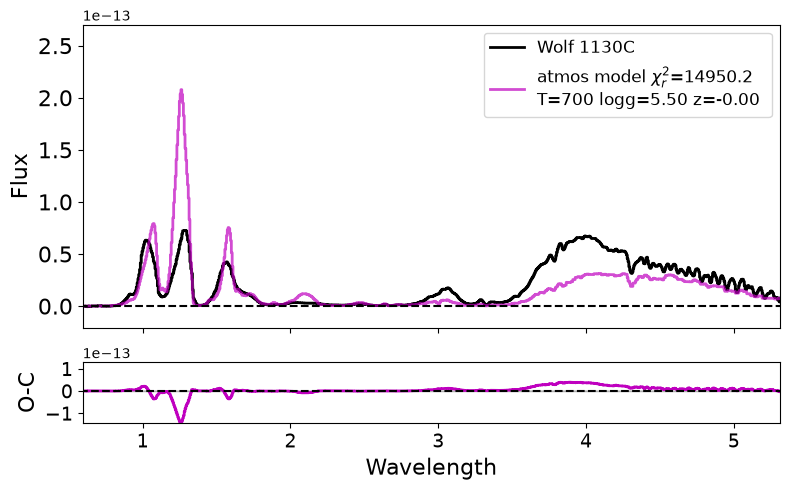

Constraining broad to within A
Constraining cld to within RO

Best parameters:
	model = atmos
	ad = 1.0
	broad = A
	cld = RO
	kzz = 0.0
	logg = 5.5
	logpmax = 4.0
	logpmin = -8.0
	teff = 1000.0
	z = -0.0
	scale = 9.220115105025209e-22
	chis = 25442773.341883477
	radius = 0.013467801702857211
	dof = 858.0
	rchi = 29653.581983547178


<Figure size 640x480 with 0 Axes>

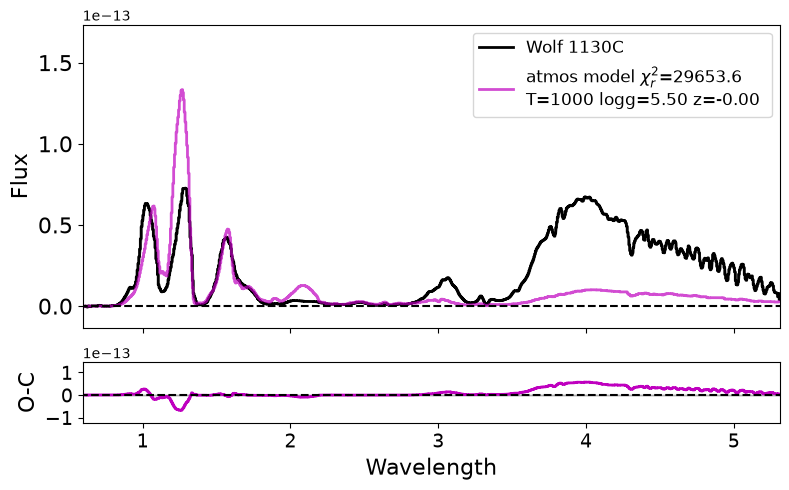

Constraining broad to within B
Constraining cld to within LC

Best parameters:
	model = atmos
	ad = 1.0
	broad = B
	cld = LC
	kzz = 0.0
	logg = 5.5
	logpmax = 4.0
	logpmin = -8.0
	teff = 900.0
	z = -0.0
	scale = 1.742349131114143e-21
	chis = 22913432.28598332
	radius = 0.018513824110524286
	dof = 858.0
	rchi = 26705.632034945596


<Figure size 640x480 with 0 Axes>

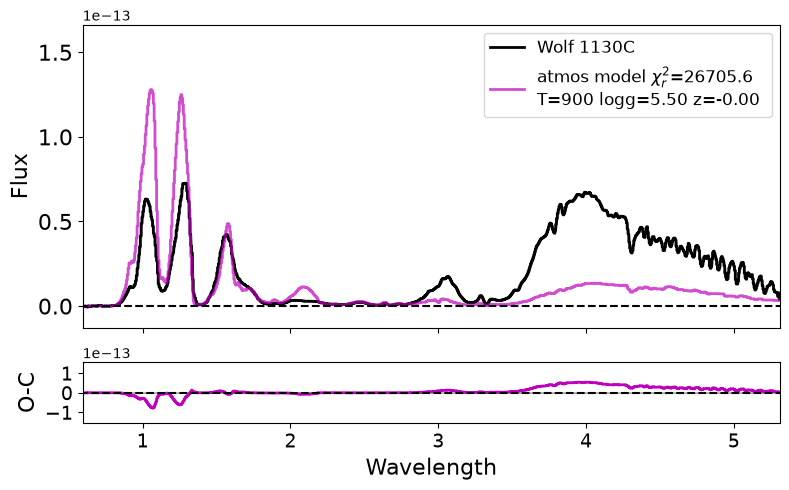

Constraining broad to within B
Constraining cld to within RO
('B', 'RO') IS A BROKEN GRID


RuntimeError: Resampled ipar 10000 without viable map

In [6]:
models, wave = ucdmcmc.getModelSet("atmo20", "JWST-NIRSPEC-PRISM")

sp = ucdmcmc.getSample("JWST-NIRSPEC-PRISM")
sp = ucdmcmc.resample(sp, wave)

lacy23_emcee = fitEMCEE(sp, models, NSTEPS=1000, initial_guess=True)

Reading in sample spectrum for instrument SPEX-PRISM of source 2MASS J0559-1404
Constraining cld to within lef22

Best parameters:
	model = sphinx25
	cld = lef22
	co = 0.5
	logg = 3.0
	mlt = 1.0
	teff = 2200.0
	z = 1.0
	scale = 5.516555283685e-21
	chis = 1190392.3005273757
	radius = 0.03294295319739136
	dof = 562.0
	rchi = 2118.135766062946


<Figure size 640x480 with 0 Axes>

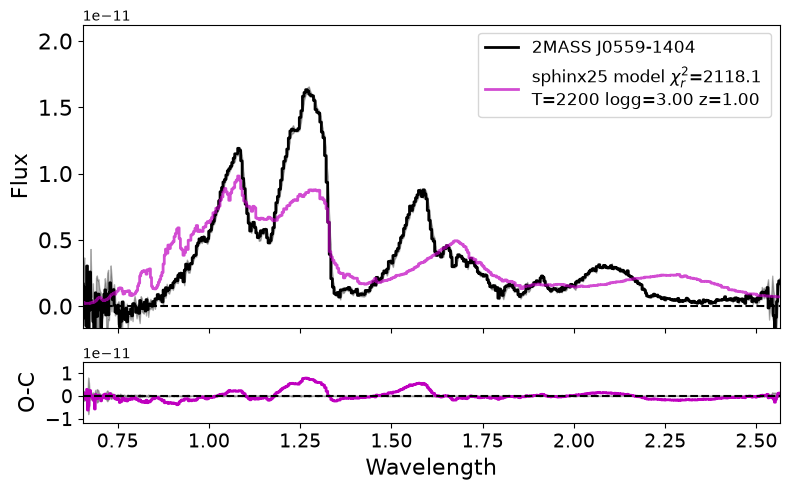

Constraining cld to within log-28

Best parameters:
	model = sphinx25
	cld = log-28
	co = 0.3
	logg = 4.0
	mlt = 1.0
	teff = 2400.0
	z = 1.0
	scale = 4.1972223035540736e-21
	chis = 1780686.2736855305
	radius = 0.028734889266067005
	dof = 562.0
	rchi = 3168.480914031193


<Figure size 640x480 with 0 Axes>

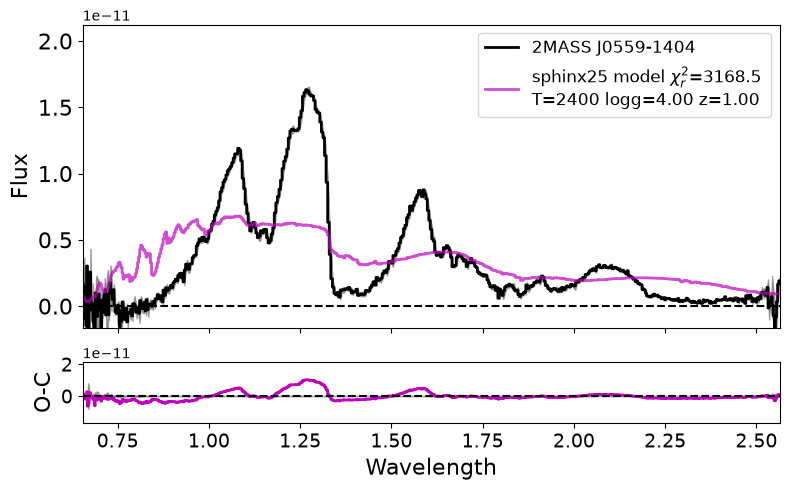

Constraining cld to within log-29

Best parameters:
	model = sphinx25
	cld = log-29
	co = 0.3
	logg = 4.0
	mlt = 0.5
	teff = 2200.0
	z = 1.0
	scale = 5.619958781822992e-21
	chis = 1480403.876834895
	radius = 0.03325026470318841
	dof = 562.0
	rchi = 2634.170599350347


<Figure size 640x480 with 0 Axes>

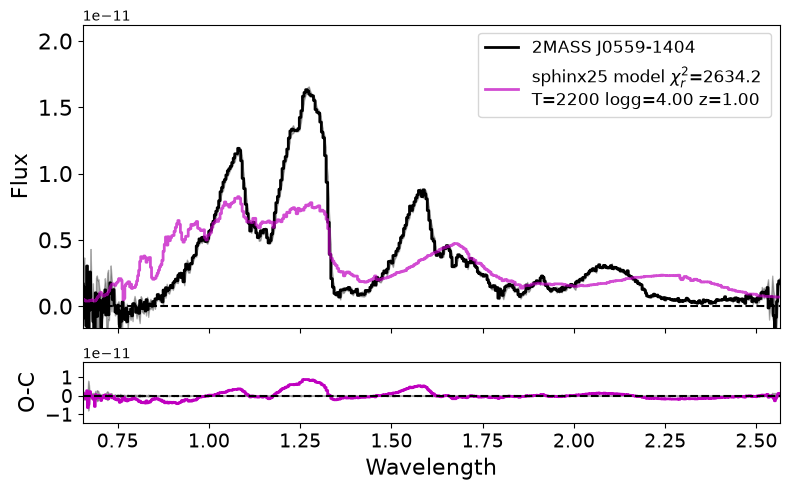

Constraining cld to within log-31

Best parameters:
	model = sphinx25
	cld = log-31
	co = 0.3
	logg = 4.0
	mlt = 1.0
	teff = 2200.0
	z = 1.0
	scale = 5.736545096601035e-21
	chis = 1467489.987822936
	radius = 0.03359338350257556
	dof = 562.0
	rchi = 2611.1921491511316


<Figure size 640x480 with 0 Axes>

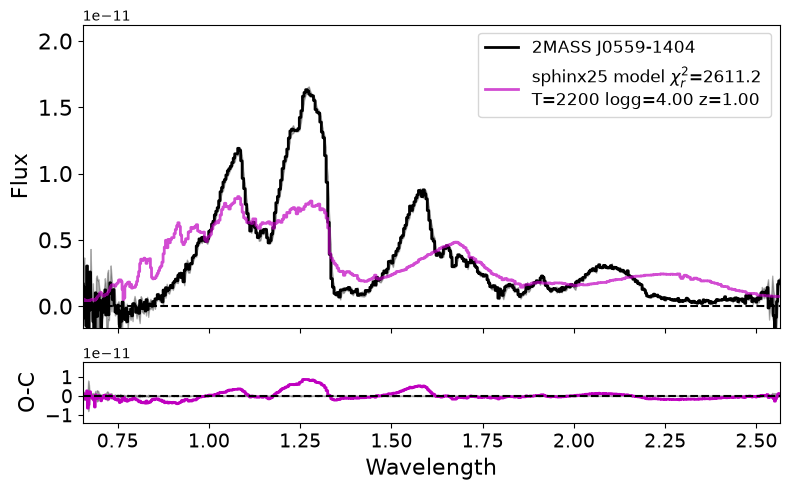

Constraining cld to within log-32

Best parameters:
	model = sphinx25
	cld = log-32
	co = 0.7
	logg = 5.0
	mlt = 1.0
	teff = 3700.0
	z = -0.25
	scale = 9.750688551964082e-22
	chis = 2097973.2669519056
	radius = 0.013849885540076491
	dof = 562.0
	rchi = 3733.0485177080172


<Figure size 640x480 with 0 Axes>

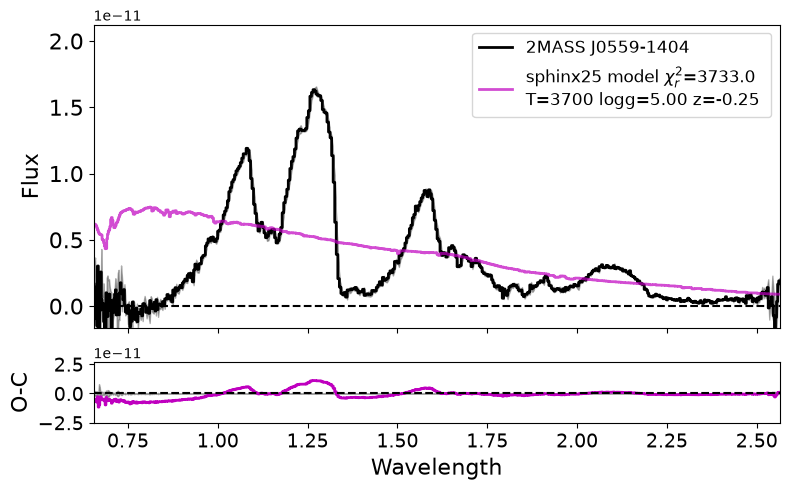

100%|██████████| 1000/1000 [00:43<00:00, 23.05it/s]


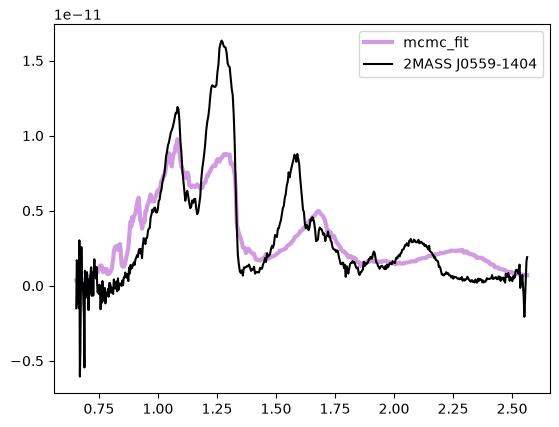

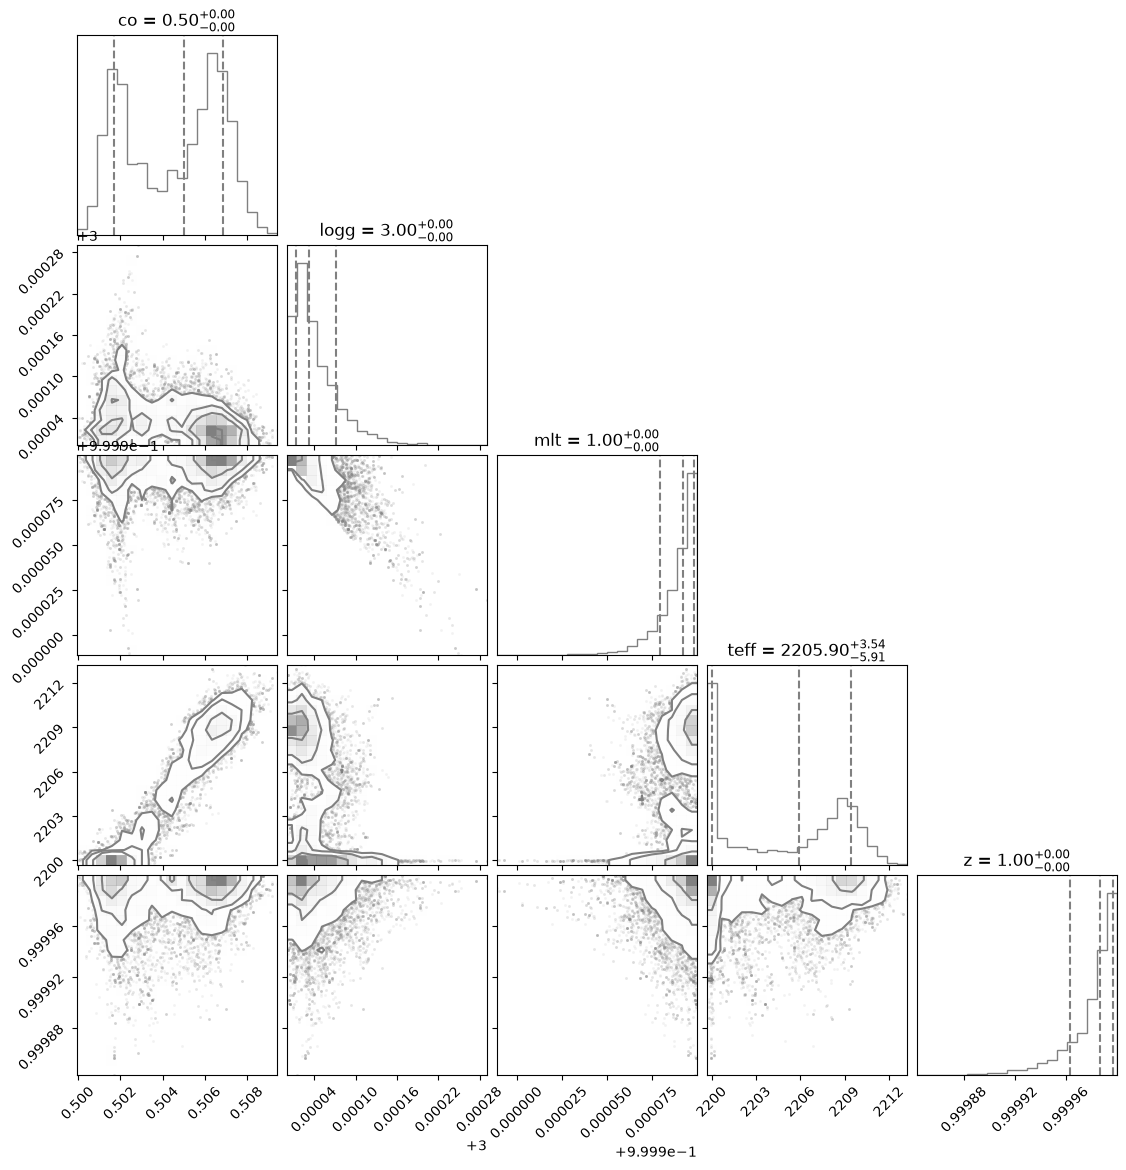

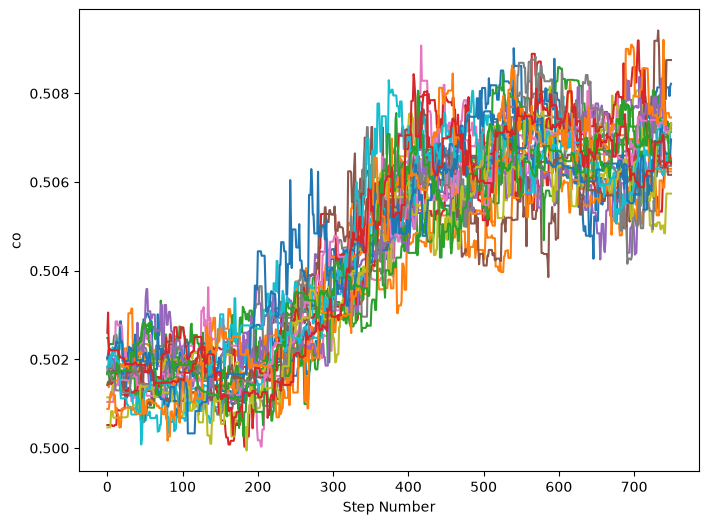

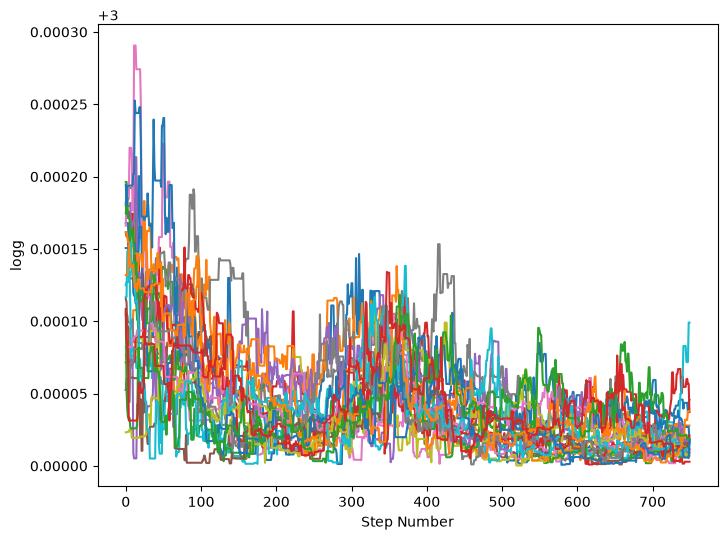

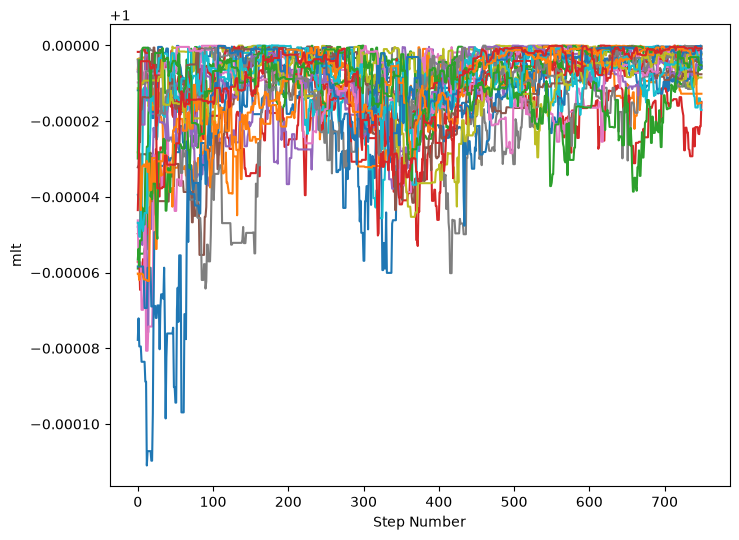

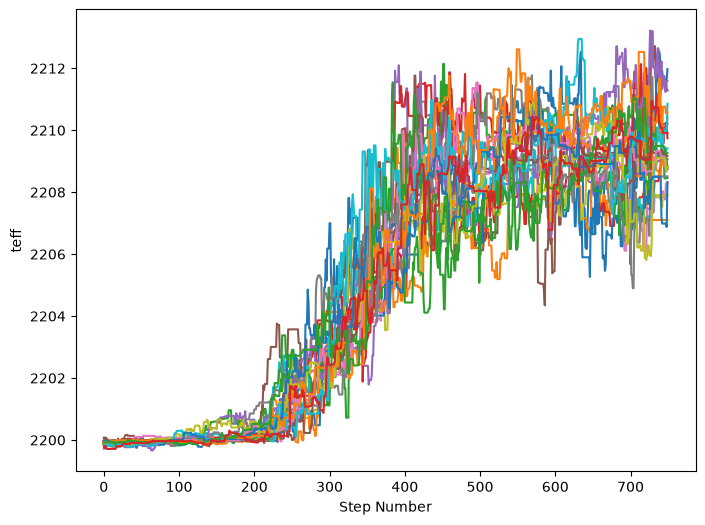

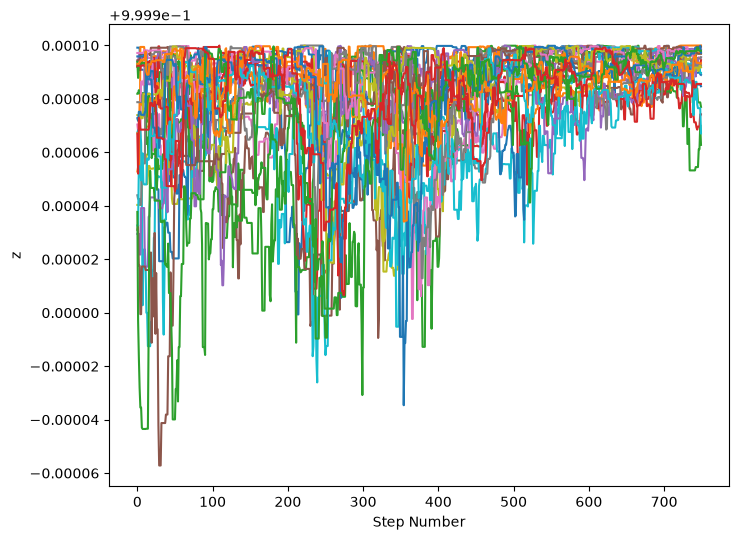

In [7]:
models, wave = ucdmcmc.getModelSet("sphinx25") # key error in fitmcmc
sp = ucdmcmc.getSample("SPEX-PRISM")

sphinx25_emcee = fitEMCEE(sp, models, NSTEPS=1000)

Reading in sample spectrum for instrument SPEX-PRISM of source 2MASS J0559-1404
('B', 'RO') DOES NOT EXIST
Constraining broad to within A
Constraining cld to within LC

Best parameters:
	model = atmos
	ad = 1.0
	broad = A
	cld = LC
	kzz = 0.0
	logg = 5.0
	logpmax = 4.0
	logpmin = -8.0
	teff = 1300.0
	z = -0.0
	scale = 5.478367986995365e-20
	chis = 53064.03798383584
	radius = 0.10381357387906431
	dof = 562.0
	rchi = 94.4199964125193


<Figure size 640x480 with 0 Axes>

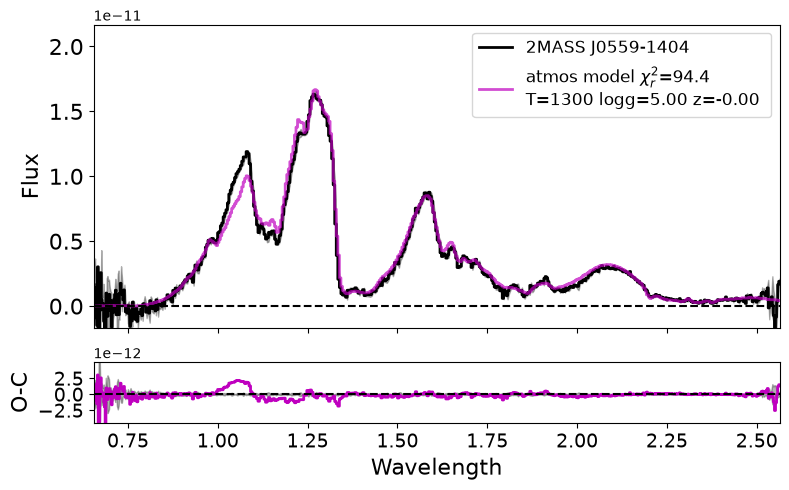

Constraining broad to within A
Constraining cld to within RO

Best parameters:
	model = atmos
	ad = 1.0
	broad = A
	cld = RO
	kzz = 0.0
	logg = 4.5
	logpmax = 4.0
	logpmin = -8.0
	teff = 1300.0
	z = -0.0
	scale = 5.497293276108107e-20
	chis = 39875.34636661155
	radius = 0.1039927338076278
	dof = 562.0
	rchi = 70.95257360607037


<Figure size 640x480 with 0 Axes>

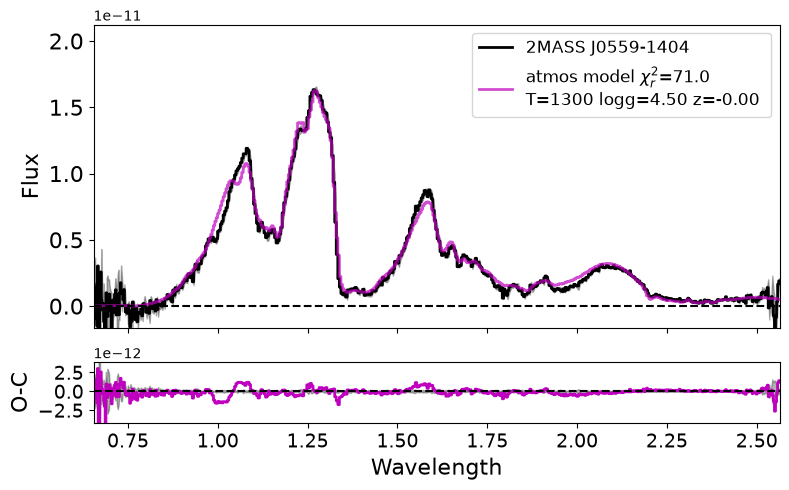

Constraining broad to within B
Constraining cld to within LC

Best parameters:
	model = atmos
	ad = 1.0
	broad = B
	cld = LC
	kzz = 0.0
	logg = 4.5
	logpmax = 4.0
	logpmin = -8.0
	teff = 1300.0
	z = -0.0
	scale = 5.326999977590408e-20
	chis = 204954.67067697423
	radius = 0.10236933671169804
	dof = 562.0
	rchi = 364.6880261156125


<Figure size 640x480 with 0 Axes>

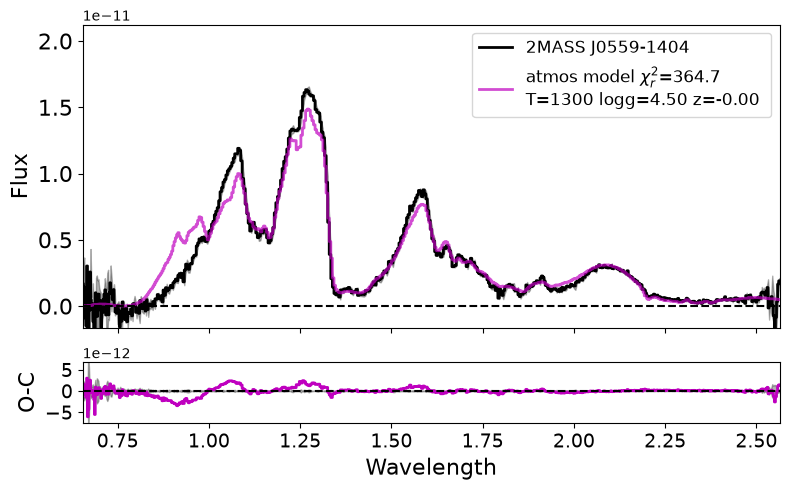

Constraining broad to within B
Constraining cld to within RO
('B', 'RO') IS A BROKEN GRID


100%|██████████| 1000/1000 [00:00<00:00, 1826.73it/s]


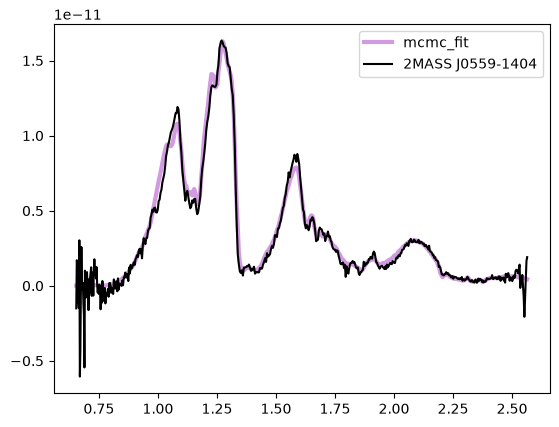

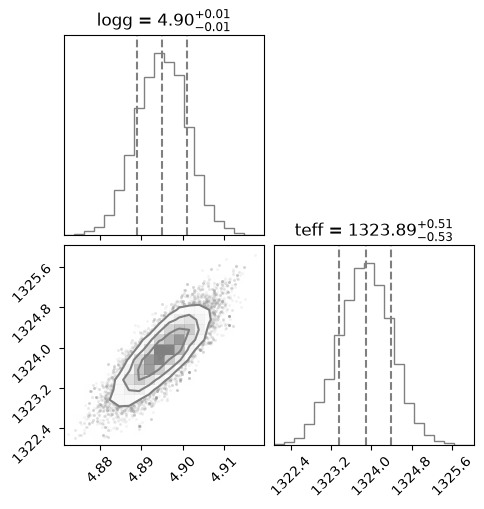

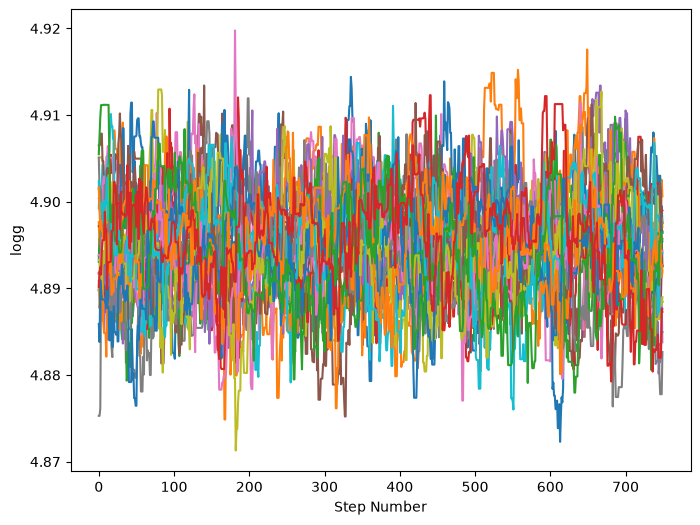

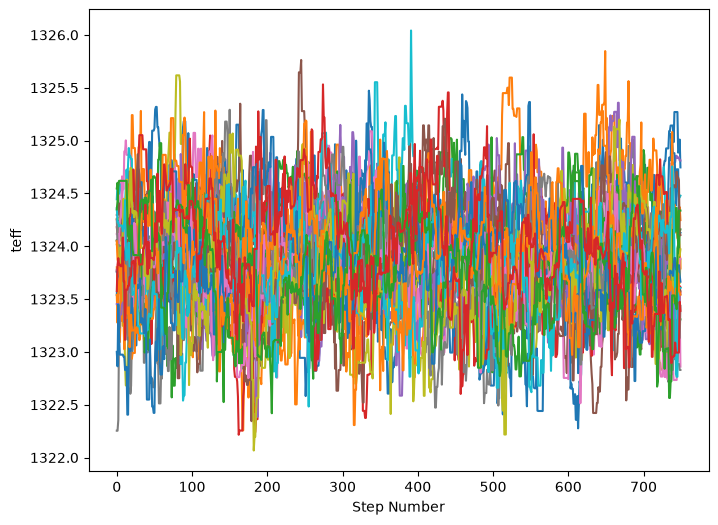

In [8]:
models, wave = ucdmcmc.getModelSet("atmo20")
sp = ucdmcmc.getSample("SPEX-PRISM")

atmo20_emcee = fitEMCEE(sp, models, NSTEPS=1000)

Reading in sample spectrum for instrument SPEX-PRISM of source 2MASS J0559-1404

Best parameters:
	model = dback24
	fsed = 10.0
	logg = 4.5
	teff = 1200.0
	z = -0.0
	scale = 7.414061310190805e-20
	chis = 65109.81205550674
	radius = 0.12076932206451087
	dof = 562.0
	rchi = 115.85375810588388


<Figure size 640x480 with 0 Axes>

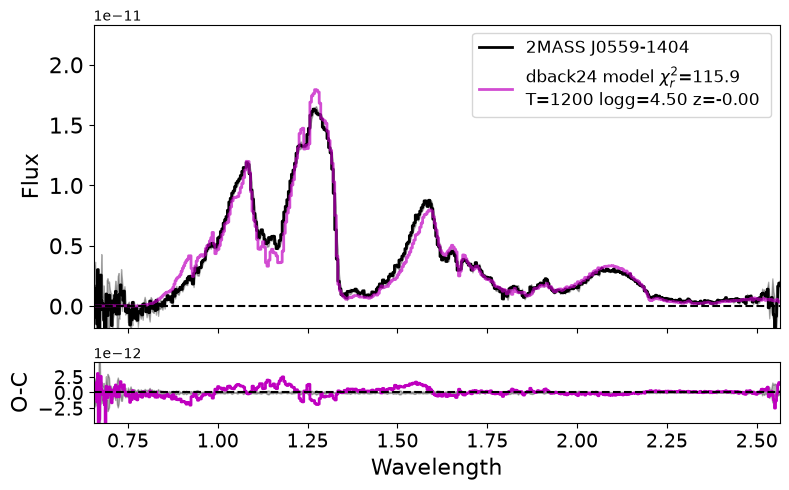

100%|██████████| 1000/1000 [00:03<00:00, 285.35it/s]


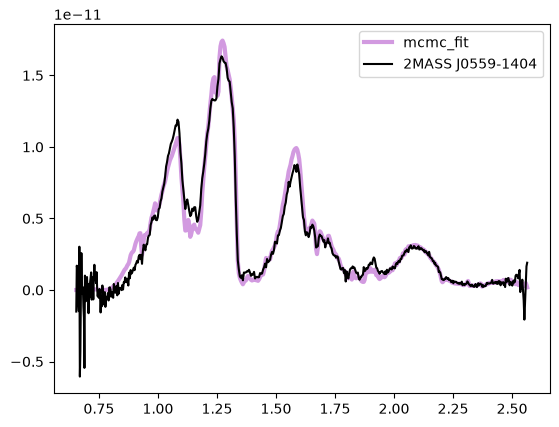

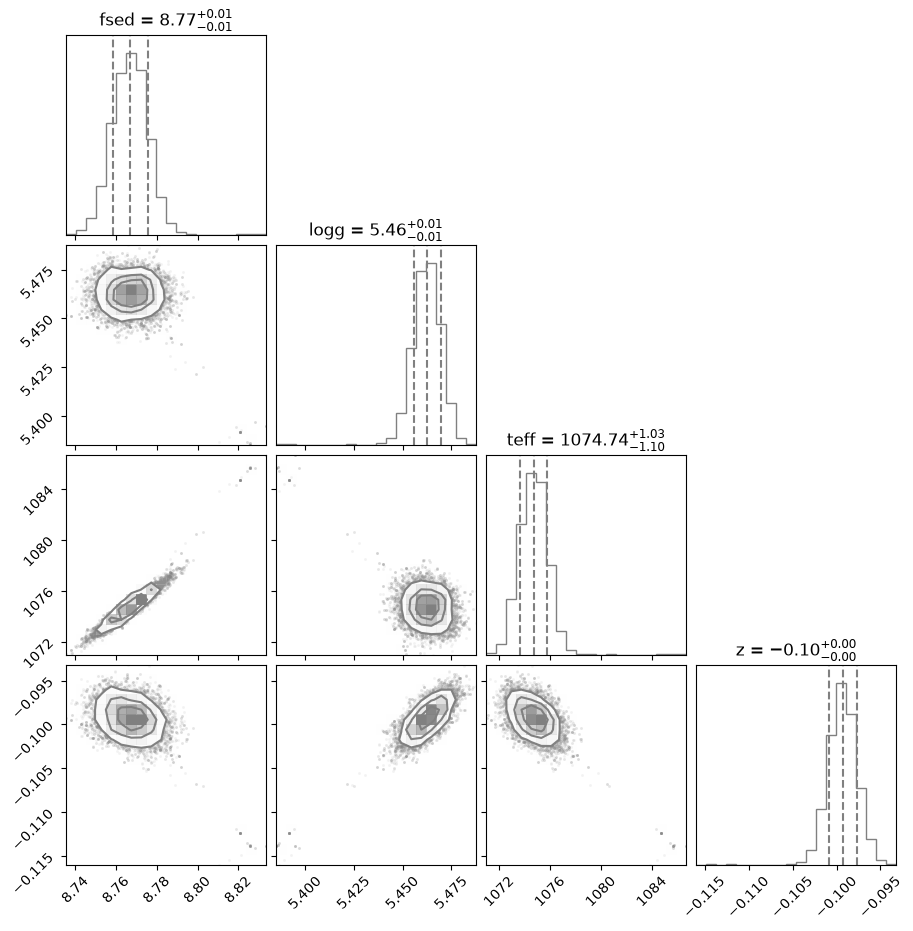

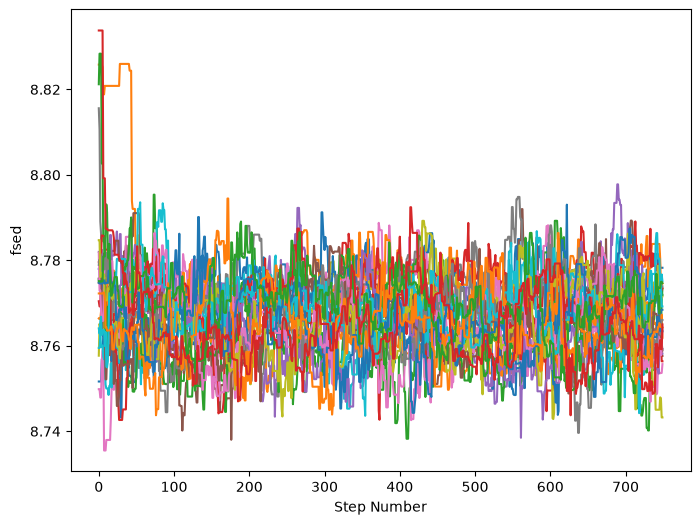

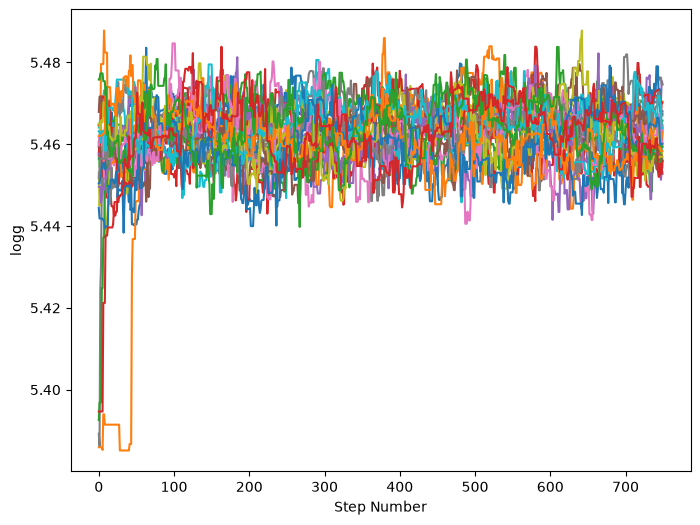

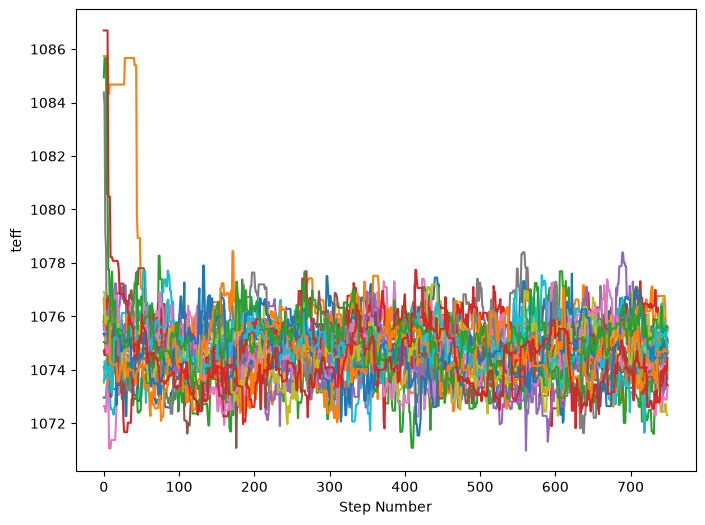

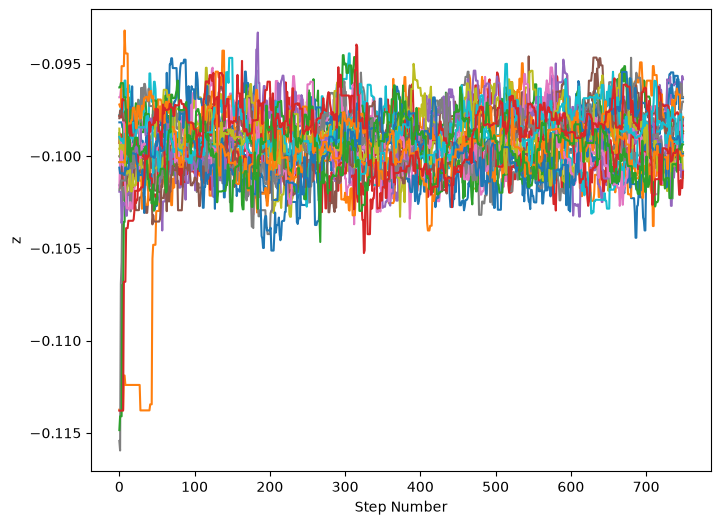

In [9]:
models, wave = ucdmcmc.getModelSet("dback24")
sp = ucdmcmc.getSample("SPEX-PRISM")

dback24_emcee = fitEMCEE(sp, models, NSTEPS=1000)

Reading in sample spectrum for instrument SPEX-PRISM of source 2MASS J0559-1404
Constraining cld to within AEE10

Best parameters:
	model = lacy23
	cld = AEE10
	kzz = -0.0
	logg = 5.0
	teff = 450.0
	z = -0.5
	scale = 3.296163907919388e-17
	chis = 1325450.4570530492
	radius = 2.546437033390534
	dof = 562.0
	rchi = 2358.452770557027


<Figure size 640x480 with 0 Axes>

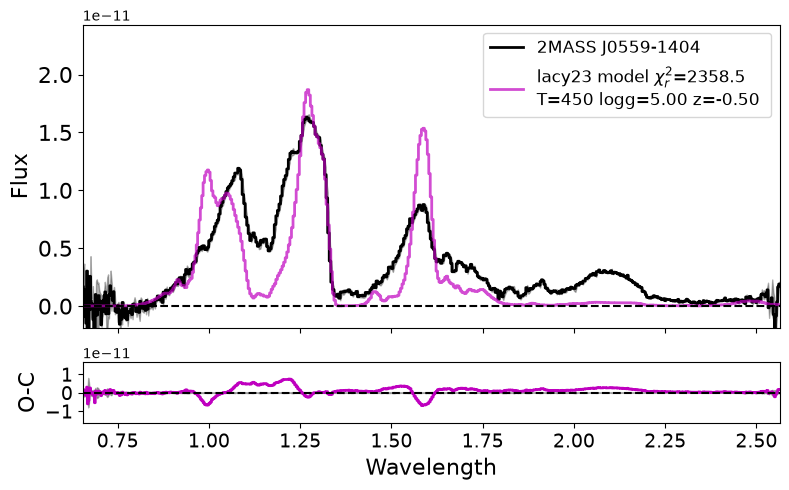

Constraining cld to within NC

Best parameters:
	model = lacy23
	cld = NC
	kzz = -0.0
	logg = 5.0
	teff = 600.0
	z = -0.5
	scale = 2.6503398163125008e-18
	chis = 1065460.4621269028
	radius = 0.7220700345075453
	dof = 562.0
	rchi = 1895.8371212222469


<Figure size 640x480 with 0 Axes>

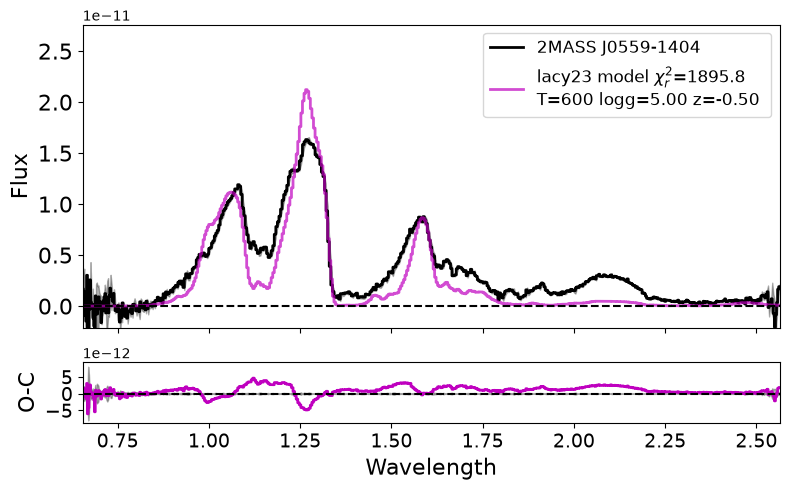

Constraining cld to within E10

Best parameters:
	model = lacy23
	cld = E10
	kzz = -0.0
	logg = 4.75
	teff = 450.0
	z = -0.5
	scale = 2.6182101982790036e-17
	chis = 1433584.662398926
	radius = 2.26950318699472
	dof = 562.0
	rchi = 2550.8623886101886


<Figure size 640x480 with 0 Axes>

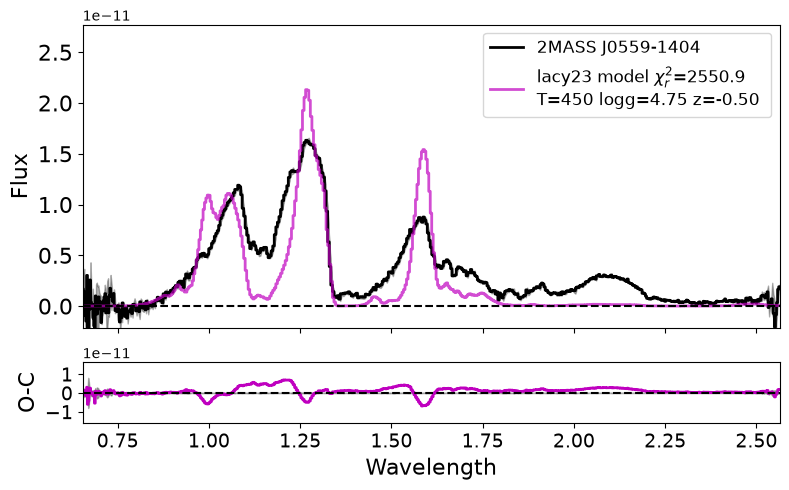

100%|██████████| 1000/1000 [00:00<00:00, 1364.79it/s]


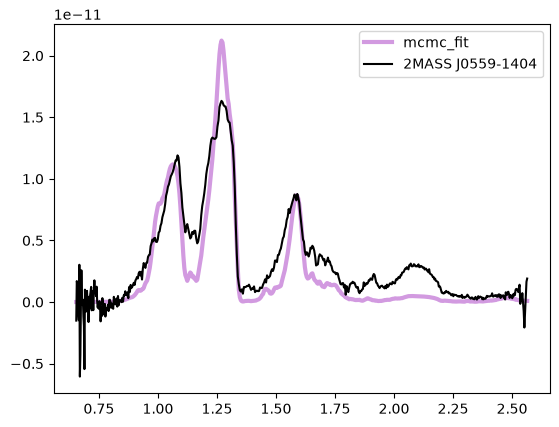

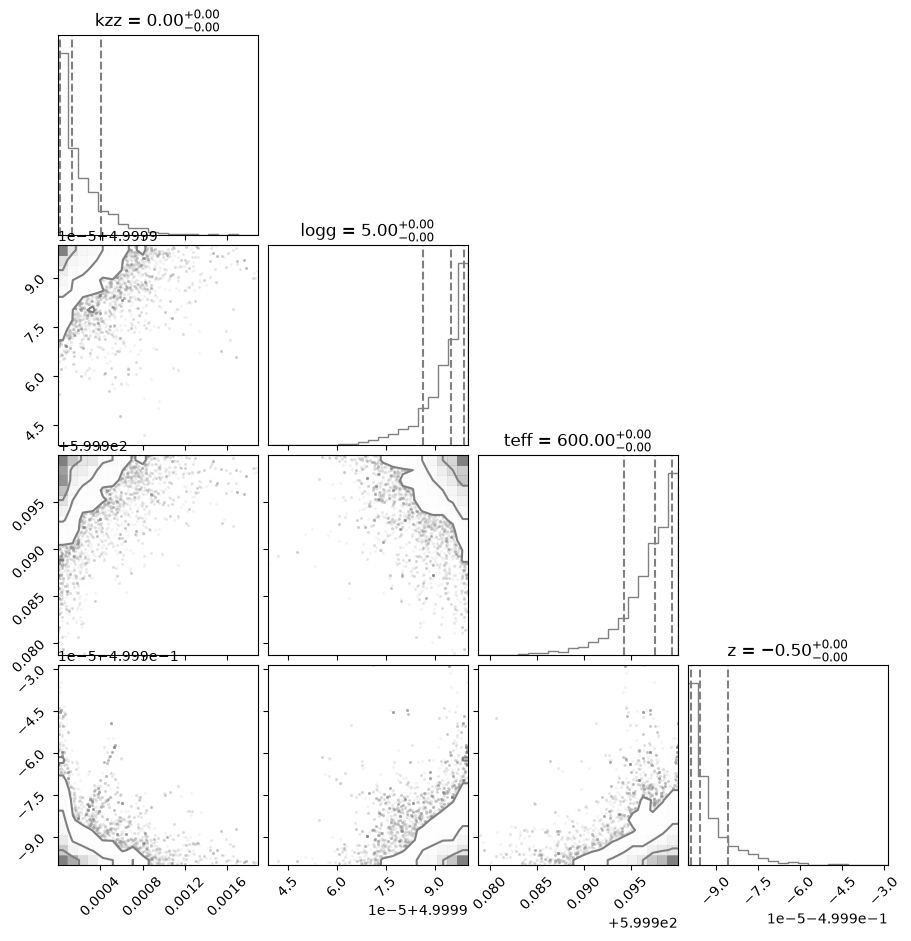

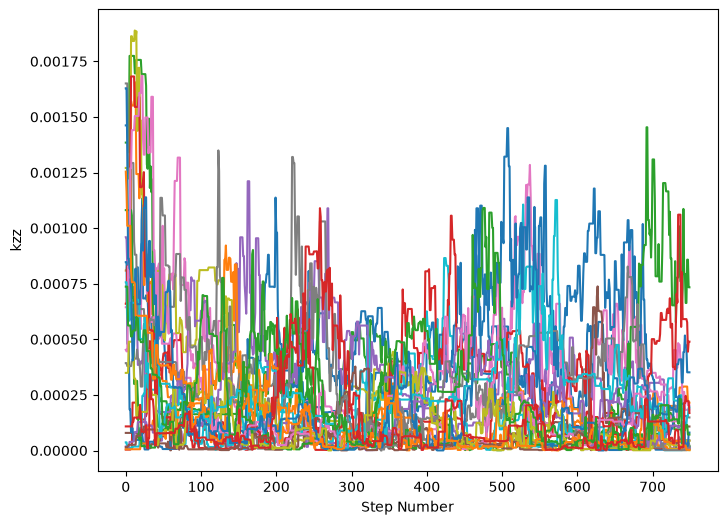

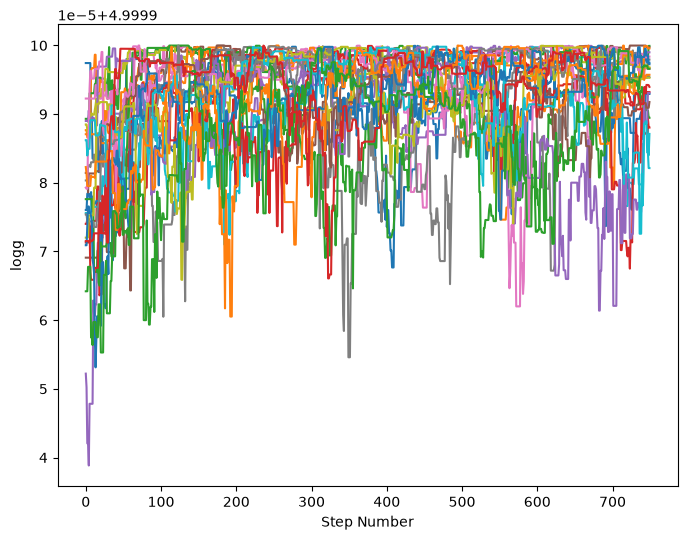

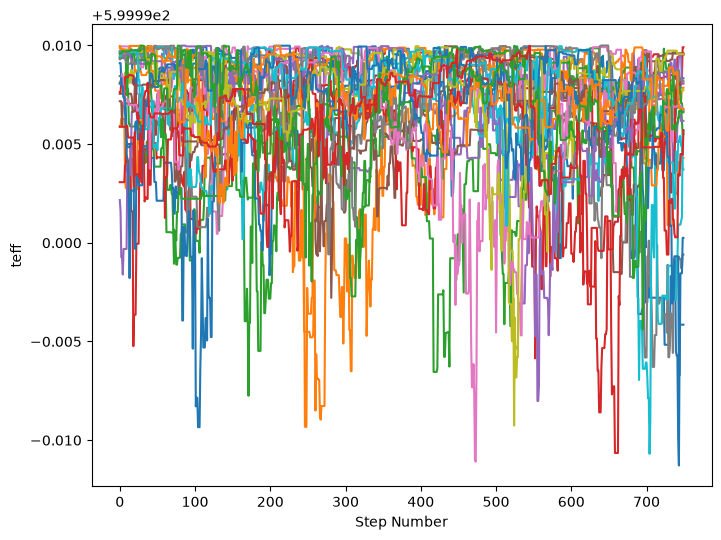

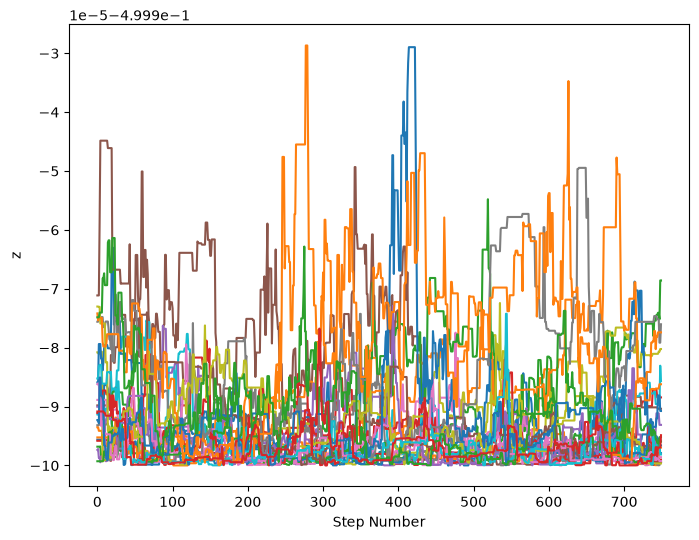

In [10]:
models, wave = ucdmcmc.getModelSet("lacy23")
sp = ucdmcmc.getSample("SPEX-PRISM")

lacy23_emcee = fitEMCEE(sp, models, NSTEPS=1000)

In [ ]:
gleep = TAPS.spec("/Users/epritchard/Research/TAPS/RUBIES_Sources/rubies-uds21-v3_prism-clear_4233_170428.spec.fits")   
gleep.toWavelengths(gleep.wave)

Reading in sample spectrum for instrument JWST-NIRSPEC-PRISM of source Wolf 1130C
('B', 'RO') DOES NOT EXIST
Constraining broad to within A
Constraining cld to within LC

Best parameters:
	model = atmos
	ad = 1.0
	broad = A
	cld = LC
	kzz = 0.0
	logg = 5.5
	logpmax = 4.0
	logpmin = -8.0
	teff = 700.0
	z = -0.0
	scale = 7.110375042661956e-21
	chis = 12827311.908011775
	radius = 0.037400275052812494
	dof = 858.0
	rchi = 14950.246979034704


<Figure size 640x480 with 0 Axes>

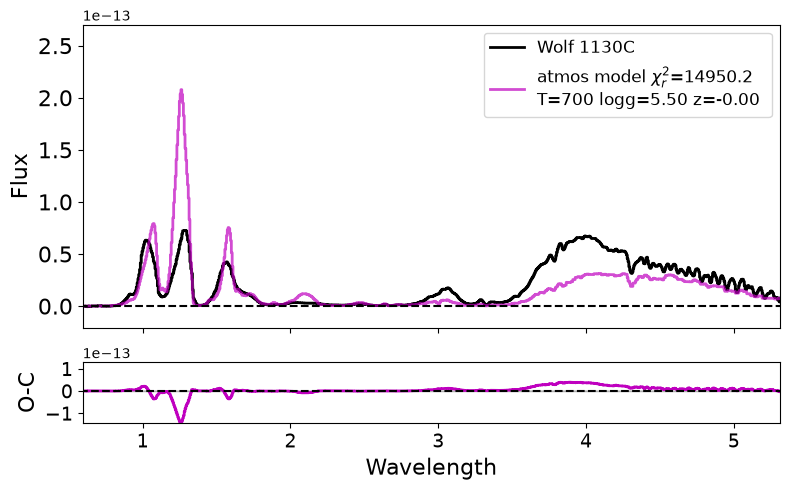

Constraining broad to within A
Constraining cld to within RO

Best parameters:
	model = atmos
	ad = 1.0
	broad = A
	cld = RO
	kzz = 0.0
	logg = 5.5
	logpmax = 4.0
	logpmin = -8.0
	teff = 1000.0
	z = -0.0
	scale = 9.220115105025209e-22
	chis = 25442773.341883477
	radius = 0.013467801702857211
	dof = 858.0
	rchi = 29653.581983547178


<Figure size 640x480 with 0 Axes>

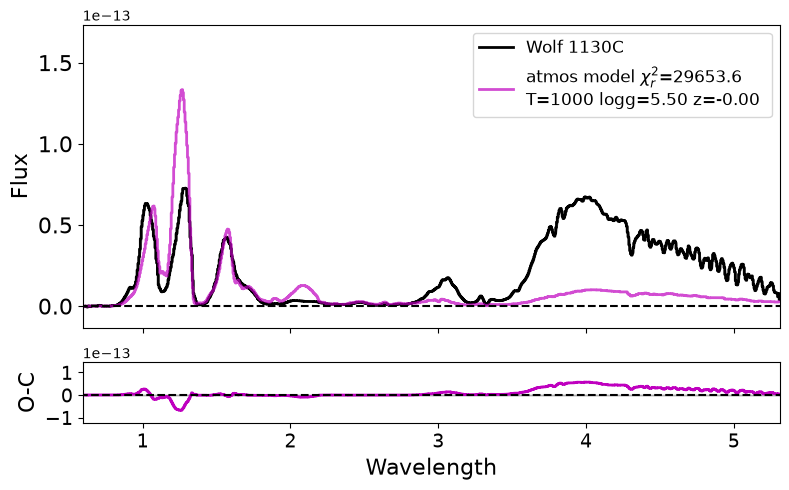

Constraining broad to within B
Constraining cld to within LC

Best parameters:
	model = atmos
	ad = 1.0
	broad = B
	cld = LC
	kzz = 0.0
	logg = 5.5
	logpmax = 4.0
	logpmin = -8.0
	teff = 900.0
	z = -0.0
	scale = 1.742349131114143e-21
	chis = 22913432.28598332
	radius = 0.018513824110524286
	dof = 858.0
	rchi = 26705.632034945596


<Figure size 640x480 with 0 Axes>

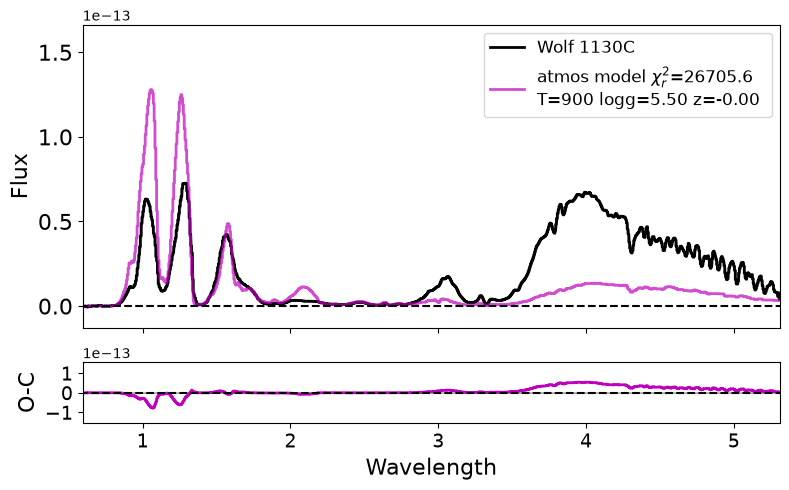

Constraining broad to within B
Constraining cld to within RO
('B', 'RO') IS A BROKEN GRID


RuntimeError: Resampled ipar 10000 without viable map

In [11]:
models, wave = ucdmcmc.getModelSet("atmo20", "JWST-NIRSPEC-PRISM")

sp = ucdmcmc.getSample("JWST-NIRSPEC-PRISM")
sp = ucdmcmc.resample(sp, wave)

lacy23_emcee = fitEMCEE(sp, models, NSTEPS=1000)

Reading in sample spectrum for instrument JWST-NIRSPEC-PRISM of source Wolf 1130C
Constraining cld to within NC

Best parameters:
	model = lacy23
	cld = NC
	kzz = 6.0
	logg = 5.0
	teff = 600.0
	z = -0.5
	scale = 1.635652897793653e-20
	chis = 3758821.6742582074
	radius = 0.056724949192090084
	dof = 858.0
	rchi = 4380.911042258983


<Figure size 640x480 with 0 Axes>

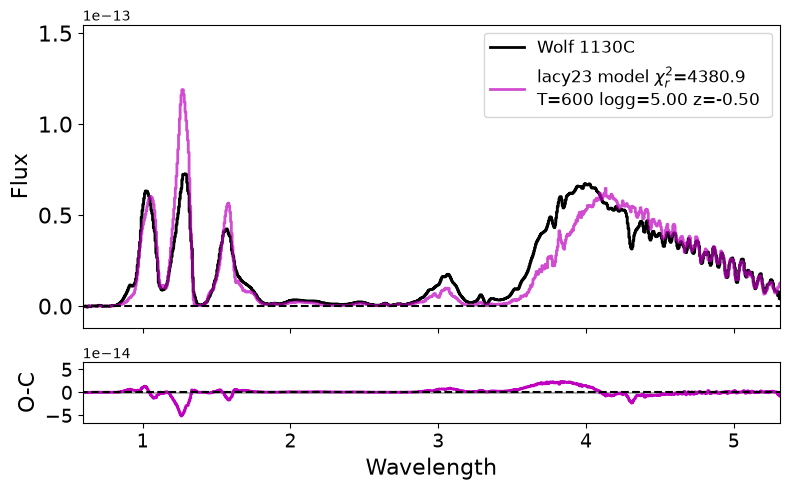

Constraining cld to within AEE10

Best parameters:
	model = lacy23
	cld = AEE10
	kzz = 6.0
	logg = 4.5
	teff = 450.0
	z = -0.5
	scale = 5.340072815458489e-20
	chis = 7470767.651299959
	radius = 0.10249487056828191
	dof = 858.0
	rchi = 8707.188404778508


<Figure size 640x480 with 0 Axes>

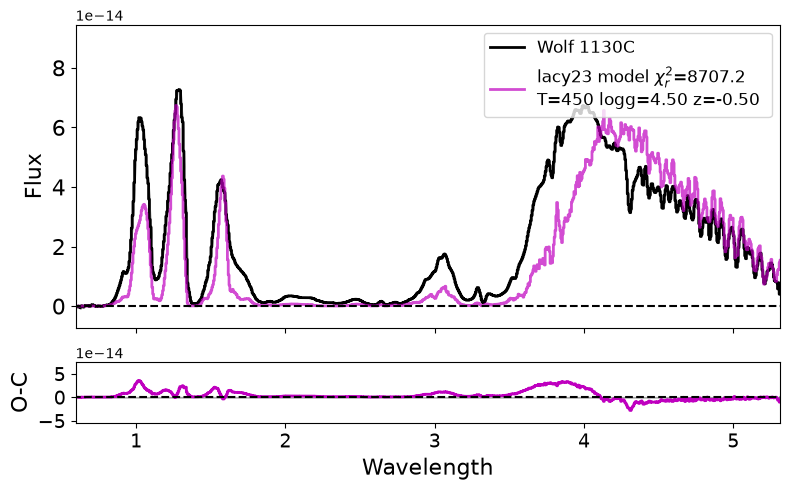

Constraining cld to within E10

Best parameters:
	model = lacy23
	cld = E10
	kzz = 6.0
	logg = 4.25
	teff = 450.0
	z = -0.5
	scale = 5.92020990475078e-20
	chis = 8308905.079532208
	radius = 0.10791879674182704
	dof = 858.0
	rchi = 9684.038554233342


<Figure size 640x480 with 0 Axes>

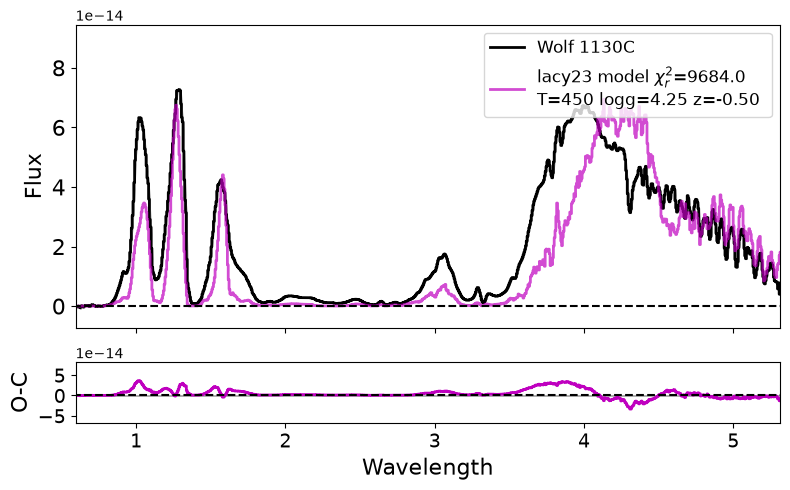

100%|██████████| 1000/1000 [00:00<00:00, 1032.51it/s]


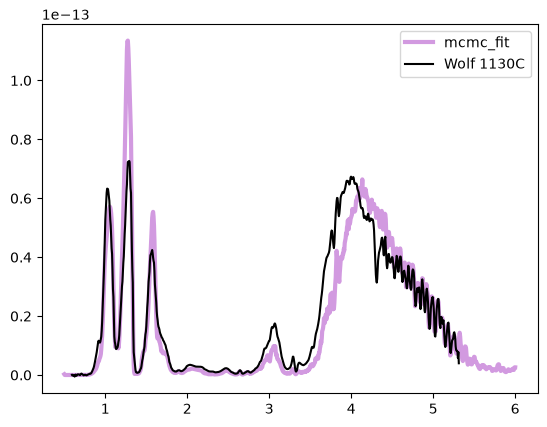

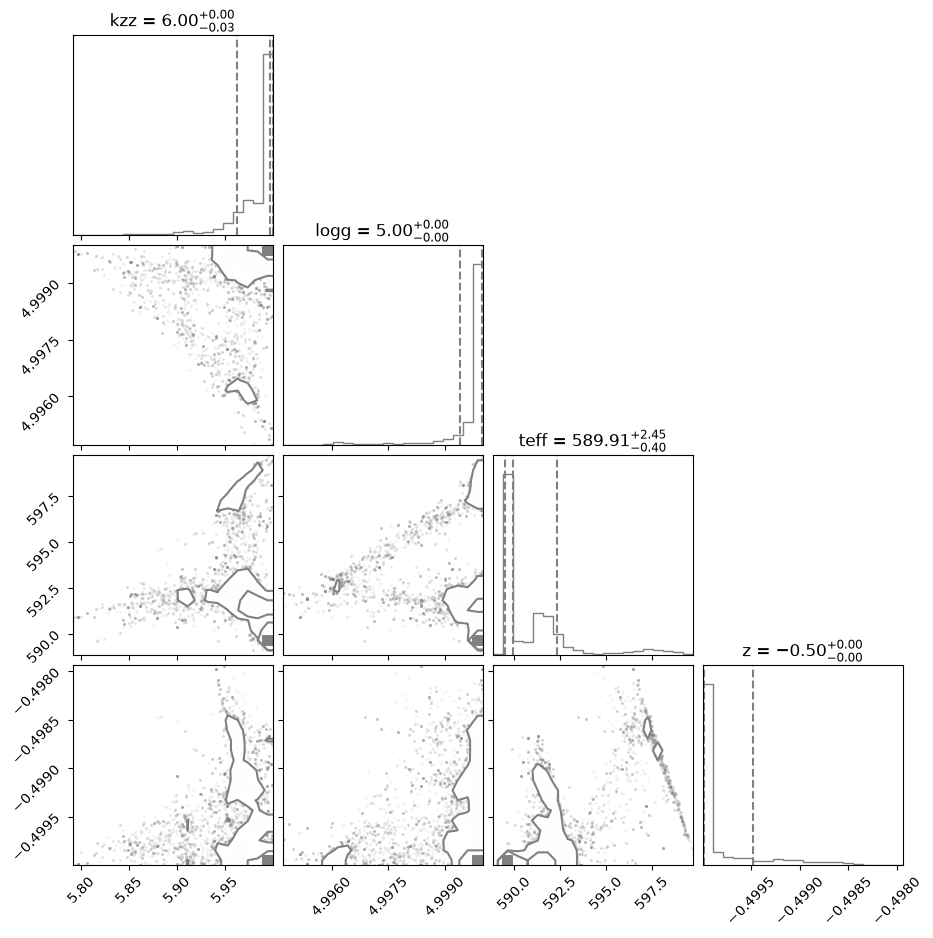

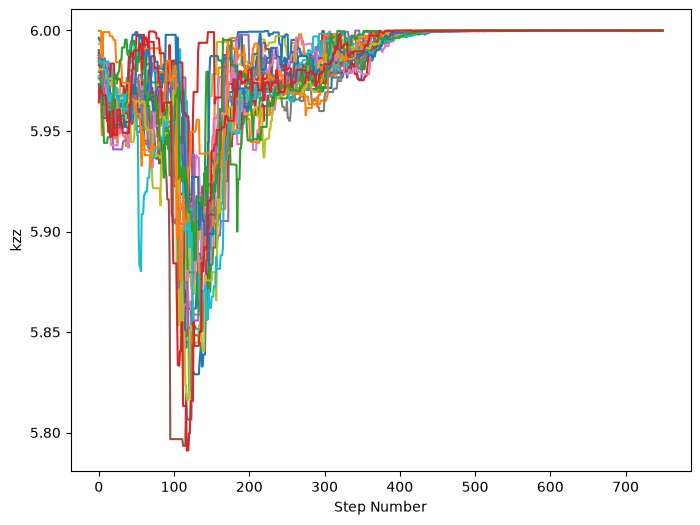

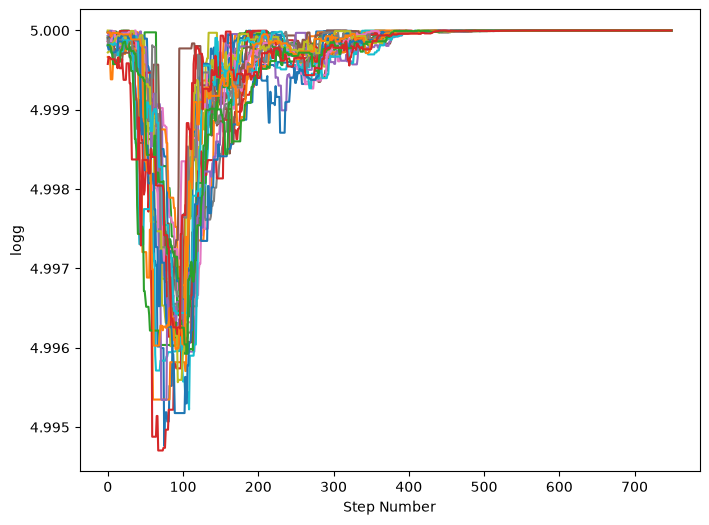

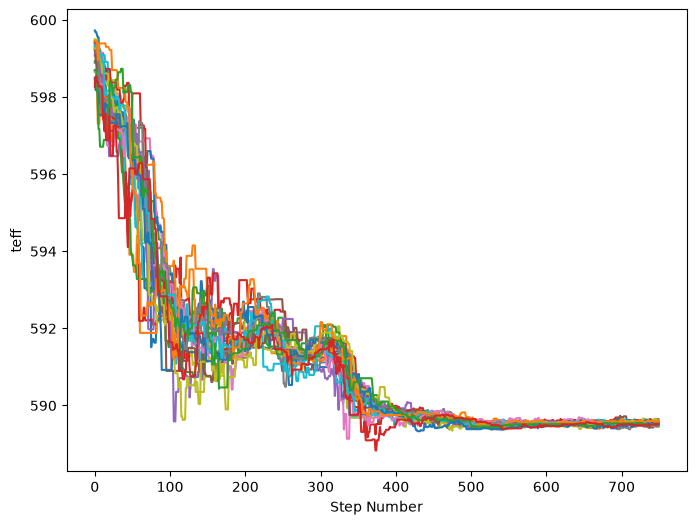

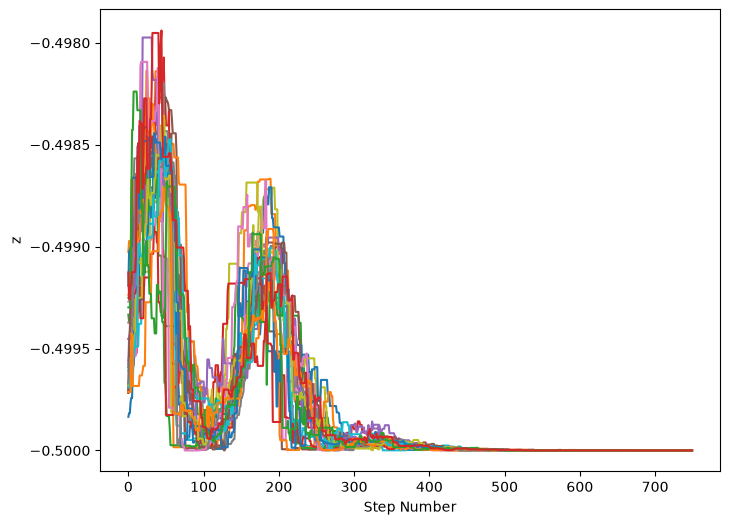

In [12]:
models, wave = ucdmcmc.getModelSet("lacy23", "JWST-NIRSPEC-PRISM")
sp = ucdmcmc.getSample("JWST-NIRSPEC-PRISM")
sp = ucdmcmc.resample(sp, wave)

lacy23_emcee = fitEMCEE(sp, models, NSTEPS=1000)

In [ ]:
# Model with NO discrete columns
# =================================
# models, wave = ucdmcmc.getModelSet("dback24")
# sp = ucdmcmc.getSample("SPEX-PRISM")

# models, wave = ucdmcmc.getModelSet("sphinx23")
# sp = ucdmcmc.getSample("SPEX-PRISM")

# models, wave = ucdmcmc.getModelSet("sonora21")
# sp = ucdmcmc.getSample("SPEX-PRISM")

# models, wave = ucdmcmc.getModelSet("newera25")
# sp = ucdmcmc.getSample("SPEX-PRISM")

# models, wave = ucdmcmc.getModelSet("lowz")
# sp = ucdmcmc.getSample("SPEX-PRISM")


# Model with 1 discrete column (3 discrete values)
# =================================
# models, wave = ucdmcmc.getModelSet("lacy23")
# sp = ucdmcmc.getSample("SPEX-PRISM")

models, wave = ucdmcmc.getModelSet("exorem21")
sp = ucdmcmc.getSample("SPEX-PRISM")


# Model with 2 discrete columns (2 discrete values each)
# =================================
# models, wave = ucdmcmc.getModelSet("atmo20")
# sp = ucdmcmc.getSample("SPEX-PRISM")


# FINAL BOSS OF TESTS:
# models, wave = ucdmcmc.getModelSet("sphinx25") # key error in fitmcmc
# sp = ucdmcmc.getSample("SPEX-PRISM")


glorp_ensemble_exorem21 = EMCEE_ensemble(models, sp)
glorp_ensemble_exorem21.get_plimits_me()
glorp_ensemble_exorem21.get_emcee_grids()
glorp_ensemble_exorem21.get_best_grid()
glorp_ensemble_exorem21.get_ipar(glorp_ensemble_exorem21.best_grid_key, 
                        initial_guess=glorp_ensemble_exorem21.best_grid
                        )
glorp_ensemble_exorem21.EnsembleSampler = emcee.EnsembleSampler(glorp_ensemble_exorem21.N_WALKERS, 
                                                                len(glorp_ensemble_exorem21.interp_cols_dict[glorp_ensemble_exorem21.best_grid_key]), 
                                                                glorp_ensemble_exorem21.log_L, 
                                                                args=(glorp_ensemble_exorem21.best_grid_key, ))
glorp_ensemble_exorem21.EnsembleSampler.run_mcmc(glorp_ensemble_exorem21.ipar, 10000, progress=True)

In [ ]:
glorp_ensemble_exorem21.plot_fit()
glorp_ensemble_exorem21.plot_steps()
glorp_ensemble_exorem21.chain_plots()

In [ ]:
models, wave = ucdmcmc.getModelSet("atmo20")
sp = ucdmcmc.getSample("SPEX-PRISM")

glorp_ensemble = EMCEE_ensemble(models, sp)
glorp_ensemble.get_plimits_me()
glorp_ensemble.get_emcee_grids()
glorp_ensemble.get_best_grid()
glorp_ensemble.get_ipar(glorp_ensemble.best_grid_key, 
                        initial_guess=glorp_ensemble.best_grid
                        )
glorp_ensemble.EnsembleSampler = emcee.EnsembleSampler(glorp_ensemble.N_WALKERS, len(glorp_ensemble.interp_cols_dict[glorp_ensemble.best_grid_key]), glorp_ensemble.log_L, args=(glorp_ensemble.best_grid_key, ))
glorp_ensemble.EnsembleSampler.run_mcmc(glorp_ensemble.ipar, 10000, progress=True)

In [ ]:
glorp_ensemble.interp_grid_dict

In [ ]:
# Model with NO discrete columns
# =================================
models, wave = ucdmcmc.getModelSet("dback24")
sp = ucdmcmc.getSample("SPEX-PRISM")

# models, wave = ucdmcmc.getModelSet("sphinx23")
# sp = ucdmcmc.getSample("SPEX-PRISM")

# models, wave = ucdmcmc.getModelSet("sonora21")
# sp = ucdmcmc.getSample("SPEX-PRISM")

# models, wave = ucdmcmc.getModelSet("newera25")
# sp = ucdmcmc.getSample("SPEX-PRISM")

# models, wave = ucdmcmc.getModelSet("lowz")
# sp = ucdmcmc.getSample("SPEX-PRISM")


# Model with 1 discrete column (3 discrete values)
# =================================
# models, wave = ucdmcmc.getModelSet("lacy23") #key error (0)
# sp = ucdmcmc.getSample("SPEX-PRISM")

# models, wave = ucdmcmc.getModelSet("exorem21") # key error in fitmcmc (0)
# sp = ucdmcmc.getSample("SPEX-PRISM")


# Model with 2 discrete columns (2 discrete values each)
# =================================
# models, wave = ucdmcmc.getModelSet("atmo20") # Works 
# sp = ucdmcmc.getSample("SPEX-PRISM")


# FINAL BOSS OF TESTS:
# models, wave = ucdmcmc.getModelSet("sphinx25") # key error in fitmcmc
# sp = ucdmcmc.getSample("SPEX-PRISM")

glorp_ensembler = fitEMCEE(sp, models)